# Import libraries

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, inspect, text
from IPython.display import display

# Load dataset and inspect data

In [2]:
# Relative path of db
db_path = Path.cwd().parent / "data" / "gas_monitoring.db"

In [3]:
# Convert full path to a string
engine = create_engine(f"sqlite:///{db_path.resolve()}")

In [4]:
# Check if successful
inspector = inspect(engine)
# Check only 1 table
if len(inspector.get_table_names()) == 1:
    print("Table found:", inspector.get_table_names()[0])
    table_name = inspector.get_table_names()[0]
else:
    print("Incorrect amount of tables found")

Table found: gas_monitoring


In [5]:
# Check amount of rows in database
with engine.connect() as connection:
    query = text(f"SELECT COUNT(*) FROM {table_name};")
    db_rows = connection.execute(query).scalar()

print(f" Total rows: {db_rows:,}")

 Total rows: 10,000


In [6]:
# Pull table
df = pd.read_sql_table(table_name, engine)
print(f"Loaded {len(df)} rows into memory.")

Loaded 10000 rows into memory.


In [7]:
df.head()

,Time of Day,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID,HVAC Operation Mode,Ambient Light Level,Activity Level
0,morning,19.63,53.83,125.486389,571.089440,478.554958,735.850412,654.625253,565.051969,2.0,7241,off,very_dim,Low Activity
1,morning,292.81,53.69,126.343018,575.789501,491.955151,740.282738,655.734327,557.078486,1.0,7241,ventilation_only,bright,Low Activity
2,morning,19.62,54.25,126.560695,585.543111,505.560808,737.112906,649.962421,558.065196,1.0,7241,eco_mode,None,Low Activity
3,morning,20.10,50.48,113.504877,597.449961,515.142272,744.020651,676.150075,600.222210,NaN,7241,eco_mode,very_bright,High Activity
4,morning,19.89,48.42,92.766225,613.654875,535.664558,770.265441,720.274019,625.731124,1.0,7241,heating_active,moderate,LowActivity


In [8]:
df.shape

(10000, 14)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Time of Day                10000 non-null  object 
 1   Temperature                10000 non-null  float64
 2   Humidity                   8072 non-null   float64
 3   CO2_InfraredSensor         10000 non-null  float64
 4   CO2_ElectroChemicalSensor  10000 non-null  float64
 5   MetalOxideSensor_Unit1     10000 non-null  float64
 6   MetalOxideSensor_Unit2     8590 non-null   float64
 7   MetalOxideSensor_Unit3     10000 non-null  float64
 8   MetalOxideSensor_Unit4     10000 non-null  float64
 9   CO_GasSensor               9166 non-null   float64
 10  Session ID                 10000 non-null  int64  
 11  HVAC Operation Mode        10000 non-null  object 
 12  Ambient Light Level        8946 non-null   object 
 13  Activity Level             10000 non-null  obje

In [10]:
# number of empty cells per column
df.isnull().sum()

Time of Day                     0
Temperature                     0
Humidity                     1928
CO2_InfraredSensor              0
CO2_ElectroChemicalSensor       0
MetalOxideSensor_Unit1          0
MetalOxideSensor_Unit2       1410
MetalOxideSensor_Unit3          0
MetalOxideSensor_Unit4          0
CO_GasSensor                  834
Session ID                      0
HVAC Operation Mode             0
Ambient Light Level          1054
Activity Level                  0
dtype: int64

### Empty cells are in 4 columns: humidity, metal oxide sensor 2, co gas sensor, and ambient light level.

# Standardise naming in columns to assist with analysis

In [11]:
# standardise HVAC names to lower case
df["HVAC Operation Mode"] = df["HVAC Operation Mode"].apply(lambda x: x.lower())
df["HVAC Operation Mode"].value_counts()

HVAC Operation Mode
cooling_active      1728
maintenance_mode    1703
eco_mode            1673
heating_active      1660
off                 1652
ventilation_only    1584
Name: count, dtype: int64

In [12]:
# Standardise activity level labels
standardised = {
    'Low Activity': 'low_activity',
    'LowActivity': 'low_activity',
    'Low_Activity': 'low_activity',
    'Moderate Activity': 'moderate_activity',
    'ModerateActivity': 'moderate_activity',
    'High Activity': 'high_activity',
}
df["Activity Level"] = df["Activity Level"].replace(standardised)

In [13]:
def show_null_rows(column_name, df=df):
    """
    Prints the entire row with missing values in the specified column in optionally specified dataframe
    """
    display(df[df[column_name].isna()])

In [14]:
def show_value_counts(condition, df=df):
    """
    Shows the value counts of categorical data when the specified condition is met

    e.g. show_value_counts(df["Temperature"] > 30)
    """
    categorical_columns = [
        "Time of Day",
        "CO_GasSensor",
        "HVAC Operation Mode",
        "Ambient Light Level",
        "Activity Level"
    ]

    if condition is not None:
        filtered_df = df[condition]
    else:
        filtered_df = df
        
    for column_name in categorical_columns:
        print(f"\nValue counts for: {column_name}")
        print(filtered_df[column_name].value_counts(dropna = False))

# Inspect rows with missing data

In [15]:
show_null_rows("Humidity")
show_value_counts(df["Humidity"].isna())

,Time of Day,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID,HVAC Operation Mode,Ambient Light Level,Activity Level
15,morning,18.53,NaN,80.148375,590.702934,596.654594,765.694890,750.303681,700.075087,0.0,1903,heating_active,very_bright,low_activity
25,afternoon,19.46,NaN,81.850351,616.549883,538.974555,764.222091,488.808765,625.088579,1.0,7241,maintenance_mode,very_dim,low_activity
30,afternoon,20.52,NaN,88.131804,614.973747,506.676587,755.728581,689.985534,611.737822,NaN,7241,cooling_active,bright,moderate_activity
36,afternoon,20.68,NaN,82.119635,618.282123,428.657481,764.534299,718.546551,637.902211,1.0,7241,cooling_active,very_bright,moderate_activity
38,morning,19.64,NaN,139.902168,579.301906,476.971294,720.978887,682.696743,607.577312,1.0,4507,off,dim,moderate_activity
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9971,afternoon,17.31,NaN,94.323686,594.188754,461.426538,726.681435,693.159035,628.618046,2.0,2679,cooling_active,None,moderate_activity
9979,night,21.33,NaN,134.623928,553.641599,414.279896,694.386273,651.722779,572.288211,2.0,4761,eco_mode,None,low_activity
9993,morning,16.84,NaN,121.589332,589.097836,502.213084,762.497500,562.849426,669.410300,0.0,5820,eco_mode,bright,low_activity
9995,evening,23.45,NaN,137.854649,544.124855,510.926349,NaN,680.916215,620.292682,1.0,2586,maintenance_mode,very_bright,low_activity



Value counts for: Time of Day
Time of Day
afternoon    524
morning      489
evening      459
night        456
Name: count, dtype: int64

Value counts for: CO_GasSensor
CO_GasSensor
1.0    907
2.0    528
0.0    244
NaN    157
3.0     78
4.0     14
Name: count, dtype: int64

Value counts for: HVAC Operation Mode
HVAC Operation Mode
eco_mode            361
cooling_active      329
maintenance_mode    315
heating_active      313
ventilation_only    308
off                 302
Name: count, dtype: int64

Value counts for: Ambient Light Level
Ambient Light Level
very_bright    642
bright         514
moderate       300
None           200
dim            173
very_dim        99
Name: count, dtype: int64

Value counts for: Activity Level
Activity Level
low_activity         1123
moderate_activity     611
high_activity         194
Name: count, dtype: int64


In [16]:
show_null_rows("MetalOxideSensor_Unit2")
show_value_counts(df["MetalOxideSensor_Unit2"].isna())

,Time of Day,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID,HVAC Operation Mode,Ambient Light Level,Activity Level
12,morning,17.79,51.15,116.555038,590.747488,456.426736,NaN,691.308364,609.604835,1.0,3418,ventilation_only,None,moderate_activity
23,morning,19.25,54.37,-2.548722,574.748934,496.938842,NaN,701.422404,638.826368,NaN,1826,ventilation_only,very_bright,moderate_activity
28,afternoon,295.04,51.34,115.203695,571.393272,499.873896,NaN,802.571265,575.355790,2.0,4761,ventilation_only,very_bright,low_activity
35,evening,24.02,48.39,128.692361,539.592438,386.797276,NaN,543.856834,477.859881,4.0,7058,maintenance_mode,bright,low_activity
49,afternoon,22.99,51.07,116.780904,532.683719,402.180211,NaN,615.559061,534.378179,4.0,4703,cooling_active,bright,low_activity
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9967,evening,24.27,NaN,214.848164,573.884352,406.396707,NaN,635.031047,543.226050,NaN,7395,cooling_active,None,low_activity
9977,evening,22.85,46.80,119.371474,586.565204,422.759013,NaN,673.232204,625.357845,2.0,9658,maintenance_mode,very_bright,high_activity
9983,afternoon,23.00,152.46,116.846743,577.424852,460.276579,NaN,675.221322,601.178927,1.0,4507,maintenance_mode,moderate,high_activity
9992,evening,22.92,46.64,119.253573,550.549792,495.301121,NaN,685.680572,619.343335,1.0,2586,heating_active,bright,high_activity



Value counts for: Time of Day
Time of Day
evening      382
afternoon    365
morning      345
night        318
Name: count, dtype: int64

Value counts for: CO_GasSensor
CO_GasSensor
1.0    661
2.0    406
0.0    174
NaN    111
3.0     49
4.0      9
Name: count, dtype: int64

Value counts for: HVAC Operation Mode
HVAC Operation Mode
maintenance_mode    260
cooling_active      235
eco_mode            233
heating_active      232
off                 229
ventilation_only    221
Name: count, dtype: int64

Value counts for: Ambient Light Level
Ambient Light Level
very_bright    463
bright         418
moderate       195
None           154
dim            121
very_dim        59
Name: count, dtype: int64

Value counts for: Activity Level
Activity Level
low_activity         810
moderate_activity    442
high_activity        158
Name: count, dtype: int64


In [17]:
show_null_rows("CO_GasSensor")
show_value_counts(df["CO_GasSensor"].isna())

,Time of Day,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID,HVAC Operation Mode,Ambient Light Level,Activity Level
3,morning,20.10,50.48,113.504877,597.449961,515.142272,744.020651,676.150075,600.222210,NaN,7241,eco_mode,very_bright,high_activity
9,night,19.81,-48.34,8.964022,595.833260,464.828130,737.958044,687.714744,622.836602,NaN,2105,ventilation_only,None,low_activity
19,afternoon,19.57,51.23,91.168499,611.561714,537.713012,751.668484,709.823944,621.493028,NaN,7241,maintenance_mode,very_bright,moderate_activity
23,morning,19.25,54.37,-2.548722,574.748934,496.938842,NaN,701.422404,638.826368,NaN,1826,ventilation_only,very_bright,moderate_activity
27,morning,292.17,50.12,79.585071,614.239997,517.352383,762.802020,549.291994,667.030718,NaN,3856,ventilation_only,very_bright,moderate_activity
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9954,afternoon,293.94,44.55,75.618247,567.044186,511.008803,753.665230,718.474331,664.598081,NaN,2586,eco_mode,very_bright,moderate_activity
9964,afternoon,21.69,44.71,81.385283,561.968352,527.330609,752.324424,718.379962,659.181524,NaN,2586,heating_active,very_dim,low_activity
9967,evening,24.27,NaN,214.848164,573.884352,406.396707,NaN,635.031047,543.226050,NaN,7395,cooling_active,None,low_activity
9980,night,292.01,52.10,118.519591,587.887196,464.160197,748.870053,712.972441,642.839403,NaN,9658,off,very_bright,moderate_activity



Value counts for: Time of Day
Time of Day
afternoon    247
night        201
evening      197
morning      189
Name: count, dtype: int64

Value counts for: CO_GasSensor
CO_GasSensor
NaN    834
Name: count, dtype: int64

Value counts for: HVAC Operation Mode
HVAC Operation Mode
off                 155
ventilation_only    147
heating_active      137
eco_mode            134
maintenance_mode    131
cooling_active      130
Name: count, dtype: int64

Value counts for: Ambient Light Level
Ambient Light Level
very_bright    284
bright         244
moderate       119
None            75
dim             66
very_dim        46
Name: count, dtype: int64

Value counts for: Activity Level
Activity Level
low_activity         492
moderate_activity    252
high_activity         90
Name: count, dtype: int64


In [18]:
show_null_rows("Ambient Light Level")
show_value_counts(df["Ambient Light Level"].isna())

,Time of Day,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID,HVAC Operation Mode,Ambient Light Level,Activity Level
2,morning,19.62,54.25,126.560695,585.543111,505.560808,737.112906,649.962421,558.065196,1.0,7241,eco_mode,None,low_activity
9,night,19.81,-48.34,8.964022,595.833260,464.828130,737.958044,687.714744,622.836602,NaN,2105,ventilation_only,None,low_activity
11,afternoon,19.71,48.68,80.161332,615.972458,575.491588,780.078308,732.349009,667.927995,0.0,7241,eco_mode,None,moderate_activity
12,morning,17.79,51.15,116.555038,590.747488,456.426736,NaN,691.308364,609.604835,1.0,3418,ventilation_only,None,moderate_activity
17,afternoon,19.73,50.62,91.736107,619.342912,527.869881,761.418621,703.674613,618.386499,0.0,7241,heating_active,None,high_activity
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9967,evening,24.27,NaN,214.848164,573.884352,406.396707,NaN,635.031047,543.226050,NaN,7395,cooling_active,None,low_activity
9971,afternoon,17.31,NaN,94.323686,594.188754,461.426538,726.681435,693.159035,628.618046,2.0,2679,cooling_active,None,moderate_activity
9976,night,20.99,57.61,-9.992761,561.460188,446.620844,703.945003,663.041519,578.163559,1.0,4761,maintenance_mode,None,low_activity
9979,night,21.33,NaN,134.623928,553.641599,414.279896,694.386273,651.722779,572.288211,2.0,4761,eco_mode,None,low_activity



Value counts for: Time of Day
Time of Day
afternoon    289
morning      271
evening      252
night        242
Name: count, dtype: int64

Value counts for: CO_GasSensor
CO_GasSensor
1.0    498
2.0    280
0.0    139
NaN     75
3.0     53
4.0      9
Name: count, dtype: int64

Value counts for: HVAC Operation Mode
HVAC Operation Mode
cooling_active      189
ventilation_only    181
heating_active      179
maintenance_mode    179
eco_mode            173
off                 153
Name: count, dtype: int64

Value counts for: Ambient Light Level
Ambient Light Level
None    1054
Name: count, dtype: int64

Value counts for: Activity Level
Activity Level
low_activity         572
moderate_activity    362
high_activity        120
Name: count, dtype: int64


### Initial inspection of missing values do not show any obvious reasons, will examine non-missing data first before deciding on what to do

## Check for duplicate data

In [19]:
# number of duplicate rows
df.duplicated().sum()

265

In [20]:
# inspect duplicate rows
display(df[df.duplicated()])
show_value_counts(df.duplicated())

,Time of Day,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID,HVAC Operation Mode,Ambient Light Level,Activity Level
493,evening,23.52,43.25,88.690954,603.702902,496.306607,747.498224,702.297867,630.522057,1.0,5693,heating_active,bright,moderate_activity
781,evening,24.84,44.60,96.529946,601.441014,467.984406,726.750458,692.238127,599.940848,1.0,9127,eco_mode,very_bright,moderate_activity
1097,morning,18.99,55.92,118.637160,600.695160,502.885955,735.720000,703.310462,615.349296,1.0,5693,ventilation_only,bright,high_activity
1252,evening,24.06,44.04,105.264563,598.388502,496.349041,735.360708,703.337182,629.341589,1.0,8374,off,moderate,moderate_activity
1423,morning,18.05,45.57,67.096257,624.539435,573.052050,782.076193,756.024200,707.783323,0.0,1482,heating_active,very_dim,moderate_activity
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9900,afternoon,24.45,47.66,112.213544,549.766466,402.473680,731.491427,672.209675,619.458403,1.0,4703,heating_active,bright,low_activity
9902,night,18.08,54.39,118.473630,587.984997,506.368702,739.635625,698.921105,617.032041,1.0,9658,cooling_active,moderate,low_activity
9910,night,20.87,57.48,134.531336,560.602244,437.401852,699.683996,651.971387,598.752654,1.0,4761,maintenance_mode,bright,low_activity
9946,evening,25.70,48.15,121.606097,539.641062,484.896859,675.467858,594.954642,537.075883,2.0,6817,maintenance_mode,moderate,moderate_activity



Value counts for: Time of Day
Time of Day
afternoon    75
morning      70
evening      64
night        56
Name: count, dtype: int64

Value counts for: CO_GasSensor
CO_GasSensor
1.0    140
2.0     72
0.0     33
3.0     10
NaN      5
4.0      5
Name: count, dtype: int64

Value counts for: HVAC Operation Mode
HVAC Operation Mode
eco_mode            50
heating_active      47
maintenance_mode    47
cooling_active      45
off                 39
ventilation_only    37
Name: count, dtype: int64

Value counts for: Ambient Light Level
Ambient Light Level
very_bright    100
bright          71
moderate        47
very_dim        22
dim             21
None             4
Name: count, dtype: int64

Value counts for: Activity Level
Activity Level
low_activity         157
moderate_activity     78
high_activity         30
Name: count, dtype: int64


### Duplicate rows also seem to be duplicated at random and will be removed

In [21]:
# remove duplicate rows
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
df.shape

(9735, 14)

## Moving on to inspection of values in individual columns

# Time of Day Column

In [22]:
# values in time of day column
df["Time of Day"].value_counts()

Time of Day
afternoon    2560
evening      2412
morning      2390
night        2373
Name: count, dtype: int64

## Time of day data is spread evenly

# Temperature Column

In [23]:
def plot_scatter(values, x_axis=None):
    """
    Plots a scatter graph of values
    Uses x axis if provided, otherwise defaults to the index of the values
    """
    plt.figure(figsize=(10, 5))
    # if no x_axis is provided, use list index
    x = x_axis if x_axis is not None else range(len(values))
    plt.scatter(x, values, alpha=0.7)
    plt.grid(True, alpha=0.3)
    plt.show()

In [24]:
def plot_distribution(column, df=df):
    """
    Plots the distribution of values
    """
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(8, 5))
    sns.histplot(data=df, x=column, kde=True, color='skyblue', bins=30)

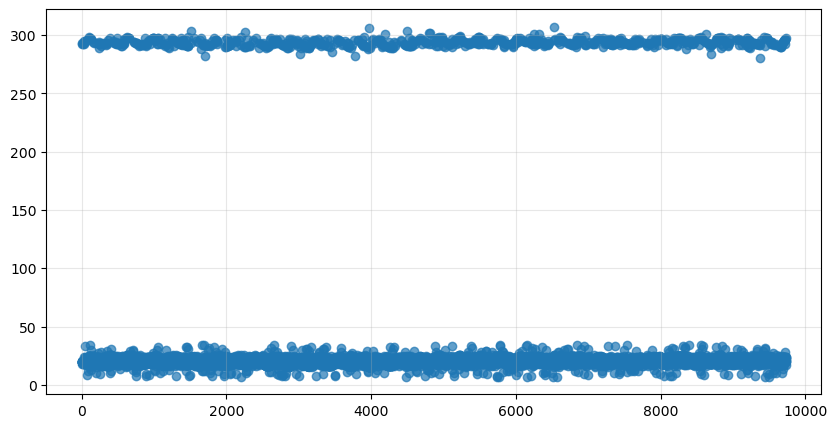

count    9735.000000
mean       42.803388
std        74.843975
min         6.903485
25%        18.930000
50%        20.510000
75%        23.190000
max       307.070000
Name: Temperature, dtype: float64

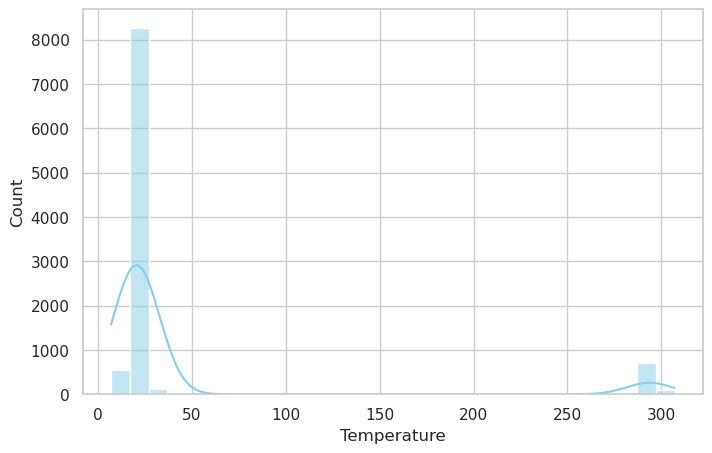

In [25]:
# Visualise and show distribution of temperature readings
plot_scatter(df["Temperature"])
plot_distribution("Temperature")
df["Temperature"].describe()

## There are extremely high temperature values that are abnormal

In [26]:
# inspect abnormally high values
high_temp_values = df[df["Temperature"] > 50]
high_temp_values

,Time of Day,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID,HVAC Operation Mode,Ambient Light Level,Activity Level
1,morning,292.81,53.69,126.343018,575.789501,491.955151,740.282738,655.734327,557.078486,1.0,7241,ventilation_only,bright,low_activity
8,afternoon,292.59,47.92,74.100322,624.577270,564.745091,798.290403,753.467986,674.278245,0.0,7241,maintenance_mode,very_bright,low_activity
24,afternoon,292.65,51.95,84.581085,617.316915,534.905951,767.204960,717.770588,617.513808,1.0,7241,eco_mode,very_bright,moderate_activity
27,morning,292.17,50.12,79.585071,614.239997,517.352383,762.802020,549.291994,667.030718,NaN,3856,ventilation_only,very_bright,moderate_activity
28,afternoon,295.04,51.34,115.203695,571.393272,499.873896,NaN,802.571265,575.355790,2.0,4761,ventilation_only,very_bright,low_activity
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9715,night,292.01,52.10,118.519591,587.887196,464.160197,748.870053,712.972441,642.839403,NaN,9658,off,very_bright,moderate_activity
9716,evening,295.61,45.84,85.732048,559.357007,511.585673,749.994773,704.264333,647.845091,1.0,2586,eco_mode,moderate,moderate_activity
9717,evening,295.67,45.89,91.771848,552.961200,515.944782,751.423006,713.109219,653.457688,1.0,2586,maintenance_mode,very_dim,high_activity
9724,night,296.17,49.35,119.874350,571.897844,413.811232,711.960225,673.048526,589.516066,2.0,1826,ventilation_only,None,low_activity


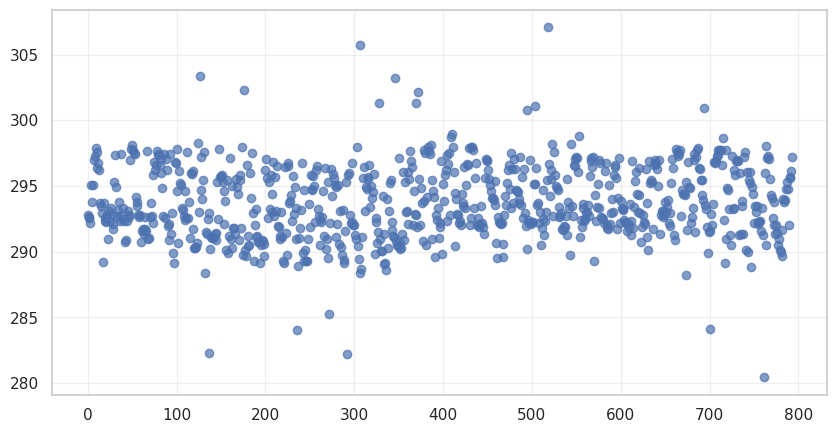

count    794.000000
mean     293.760327
std        2.791111
min      280.450000
25%      291.917500
50%      293.360000
75%      295.870000
max      307.070000
Name: Temperature, dtype: float64

Value counts for: Time of Day
Time of Day
evening      229
morning      206
afternoon    185
night        174
Name: count, dtype: int64

Value counts for: CO_GasSensor
CO_GasSensor
1.0    357
2.0    231
0.0     99
NaN     72
3.0     31
4.0      4
Name: count, dtype: int64

Value counts for: HVAC Operation Mode
HVAC Operation Mode
off                 147
eco_mode            142
maintenance_mode    132
ventilation_only    128
cooling_active      126
heating_active      119
Name: count, dtype: int64

Value counts for: Ambient Light Level
Ambient Light Level
very_bright    284
bright         221
moderate       108
None            76
dim             60
very_dim        45
Name: count, dtype: int64

Value counts for: Activity Level
Activity Level
low_activity         456
moderate_activity    262
high_

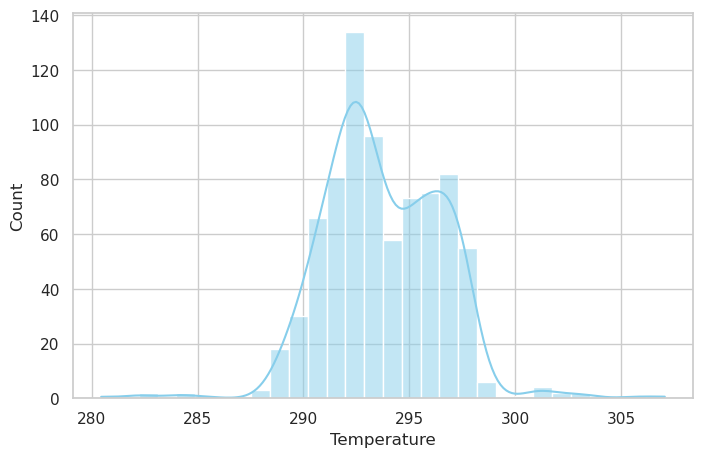

In [27]:
# visualise temperature above 50
plot_scatter(high_temp_values["Temperature"])
plot_distribution("Temperature", df = high_temp_values)
print(high_temp_values["Temperature"].describe())
show_value_counts(None, df= high_temp_values)

## The high temperature values seem to be random

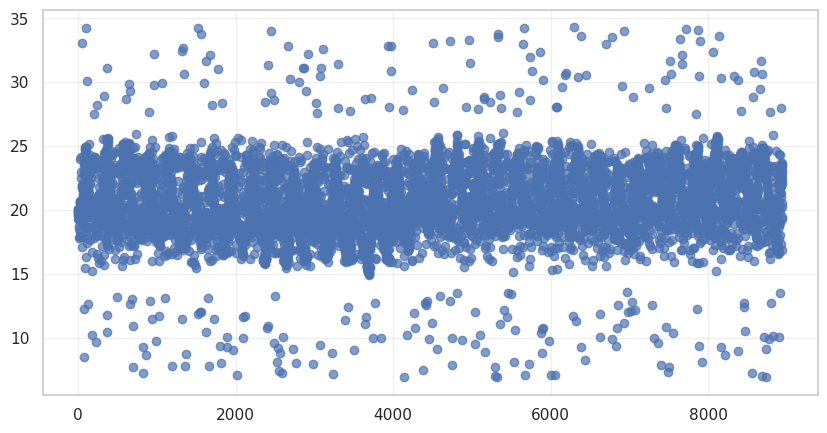

count    8941.000000
mean       20.517312
std         2.870148
min         6.903485
25%        18.830000
50%        20.190000
75%        22.580000
max        34.301271
Name: Temperature, dtype: float64

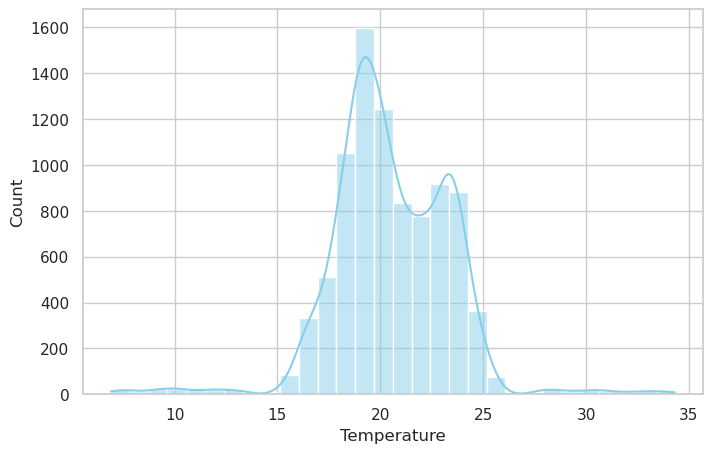

In [29]:
# visualise the rest of the temperature data
plot_scatter(df[df["Temperature"] < 50]["Temperature"])
plot_distribution("Temperature",df = df[df["Temperature"] < 50])
df[df["Temperature"] < 50]["Temperature"].describe()

## If assuming that the abnormally high temperatures have been multiplied by 10

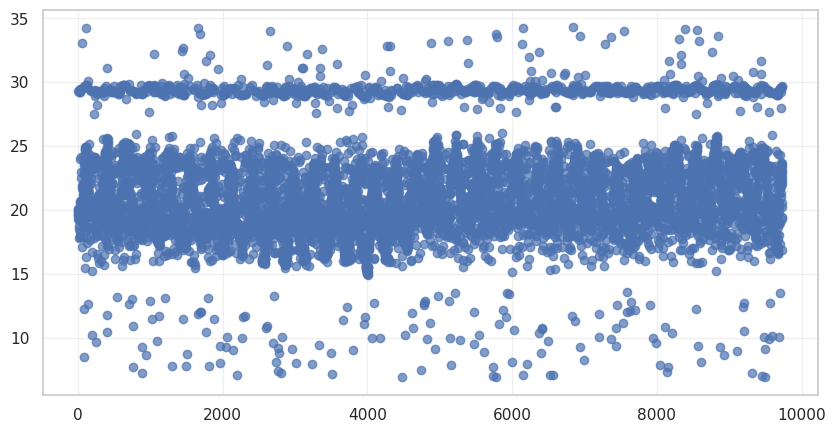

count    9735.000000
mean       21.239841
std         3.667613
min         6.903485
25%        18.930000
50%        20.510000
75%        23.190000
max        34.301271
Name: Temperature, dtype: float64

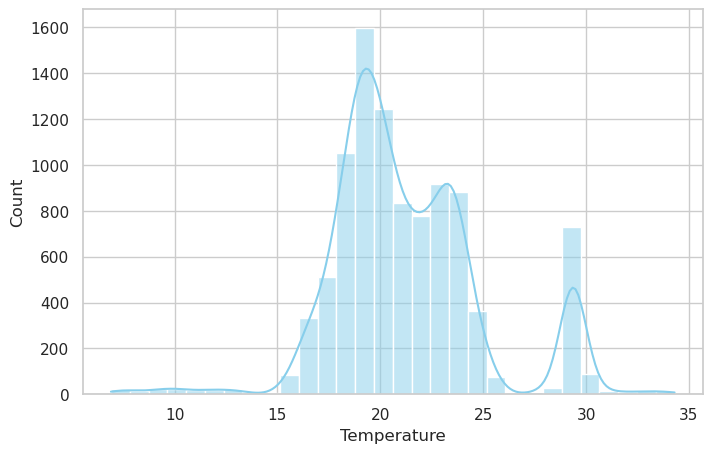

In [30]:
# make a copy to test hypothesis
testing_df = df.copy()
# divide high temperatures by 10
testing_df.loc[testing_df['Temperature'] > 50, 'Temperature'] /= 10
# visualise
plot_scatter(testing_df["Temperature"])
plot_distribution("Temperature", df = testing_df)
testing_df["Temperature"].describe()

## If assuming that the abnormally high temperature values are in Kelvin

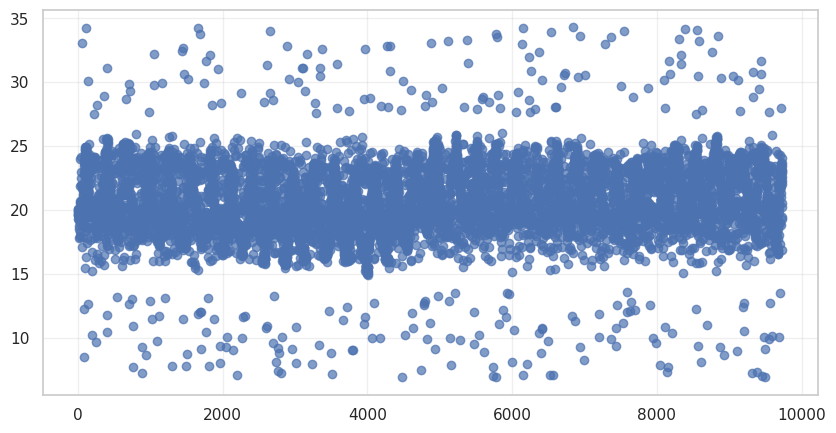

count    9735.000000
mean       20.524898
std         2.863756
min         6.903485
25%        18.830000
50%        20.190000
75%        22.600000
max        34.301271
Name: Temperature, dtype: float64

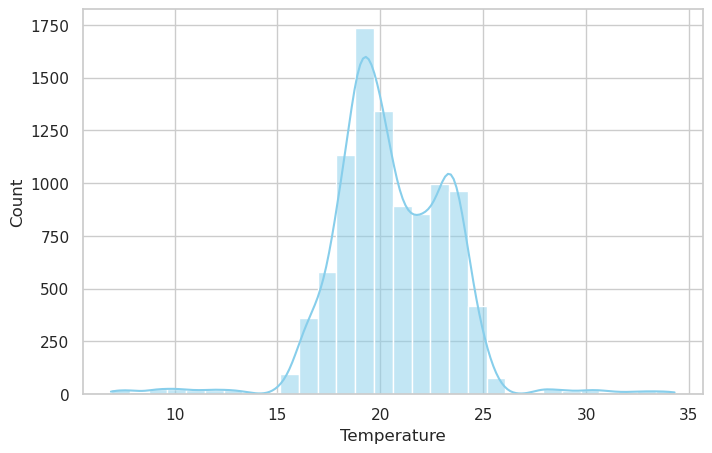

In [31]:
# make a copy to test hypothesis
testing_df = df.copy()
# minus high temperature by 273.15
testing_df.loc[testing_df['Temperature'] > 50, 'Temperature'] -= 273.15
# visualise
plot_scatter(testing_df["Temperature"])
plot_distribution("Temperature", df = testing_df)
testing_df["Temperature"].describe()

## Between the two assumptions, assuming that the abnormally high temperature values are in Kelvin and correcting them produces temperature values that are consistent with the rest of the data. Therefore, it will be assumed that the high values were recorded in Kelvin

In [32]:
# applying the same change to the original dataframe
df.loc[df['Temperature'] > 50, 'Temperature'] -= 273.15

In [33]:
# inspect high temperature values
display(df[df["Temperature"] > 30])
show_value_counts(df["Temperature"] > 30)

,Time of Day,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID,HVAC Operation Mode,Ambient Light Level,Activity Level
54,morning,33.041318,51.67,105.630998,596.534869,486.448341,747.038731,712.401956,628.500943,1.0,8374,cooling_active,moderate,high_activity
111,evening,34.239708,NaN,118.441217,595.729435,452.272956,723.133913,485.407246,592.647198,2.0,7241,maintenance_mode,very_bright,low_activity
133,evening,30.060079,52.67,118.153494,599.747325,421.326002,711.865910,652.665558,591.103827,3.0,7241,eco_mode,very_bright,low_activity
407,afternoon,31.100551,52.83,118.288369,552.688992,462.830697,681.298560,600.175993,544.795447,2.0,7058,heating_active,None,low_activity
1053,evening,32.197490,47.23,105.385537,591.210696,474.922904,739.474129,684.811562,611.941445,1.0,9658,eco_mode,very_bright,low_activity
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9050,afternoon,30.466123,52.05,117.532450,539.323051,474.100402,711.941508,669.027852,602.710548,2.0,1458,cooling_active,very_bright,low_activity
9117,afternoon,30.142086,125.88,116.780904,532.683719,402.180211,705.410192,615.559061,534.378179,4.0,4703,cooling_active,bright,low_activity
9330,morning,30.779348,50.17,100.064692,550.161557,458.934474,725.118787,639.296548,574.862978,2.0,4703,off,very_bright,low_activity
9436,evening,31.677019,48.76,103.291036,551.113497,443.834025,732.176971,688.450618,617.830907,1.0,4703,ventilation_only,bright,moderate_activity



Value counts for: Time of Day
Time of Day
morning      25
afternoon    18
evening      14
night        14
Name: count, dtype: int64

Value counts for: CO_GasSensor
CO_GasSensor
1.0    38
2.0    17
0.0     7
NaN     5
3.0     2
4.0     2
Name: count, dtype: int64

Value counts for: HVAC Operation Mode
HVAC Operation Mode
cooling_active      17
off                 14
maintenance_mode    13
ventilation_only    11
eco_mode             8
heating_active       8
Name: count, dtype: int64

Value counts for: Ambient Light Level
Ambient Light Level
bright         24
very_bright    20
moderate        9
dim             8
None            5
very_dim        5
Name: count, dtype: int64

Value counts for: Activity Level
Activity Level
low_activity         44
moderate_activity    17
high_activity        10
Name: count, dtype: int64


In [34]:
# inspect low temperature values
display(df[df["Temperature"] < 15])
show_value_counts(df["Temperature"] < 15)

,Time of Day,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID,HVAC Operation Mode,Ambient Light Level,Activity Level
80,evening,8.499293,51.84,104.237654,609.733706,473.936972,NaN,676.306256,608.415572,1.0,7241,heating_active,bright,low_activity
89,night,12.229653,47.32,111.790594,577.632466,444.180853,723.045899,696.629900,611.205888,2.0,6431,heating_active,very_bright,low_activity
137,night,12.614772,52.79,115.635688,550.871360,471.867654,697.028391,636.657652,571.409105,1.0,6817,off,bright,low_activity
198,night,10.233207,56.94,111.733666,591.270244,458.709013,728.708661,859.125193,612.345406,3.0,7241,heating_active,None,low_activity
252,morning,9.691520,48.13,81.914994,612.981958,545.951108,768.793812,745.684560,664.890366,2.0,3856,ventilation_only,very_bright,moderate_activity
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9547,night,9.902174,NaN,93.863652,559.891665,489.564057,749.978097,542.993713,632.326626,1.0,9241,ventilation_only,very_bright,high_activity
9568,morning,12.702877,50.07,62.835035,614.971921,586.409119,781.033651,751.944760,693.920387,NaN,4129,eco_mode,moderate,moderate_activity
9591,evening,10.152654,47.09,113.662748,586.588217,425.938439,743.931645,699.069839,636.930028,1.0,5820,off,very_dim,moderate_activity
9680,afternoon,10.032879,44.70,64.945329,572.230665,547.016366,781.940559,563.421191,698.455061,0.0,2586,heating_active,very_bright,moderate_activity



Value counts for: Time of Day
Time of Day
morning      44
afternoon    39
evening      36
night        36
Name: count, dtype: int64

Value counts for: CO_GasSensor
CO_GasSensor
1.0    79
2.0    35
0.0    23
NaN    11
3.0     6
4.0     1
Name: count, dtype: int64

Value counts for: HVAC Operation Mode
HVAC Operation Mode
heating_active      31
off                 28
eco_mode            28
maintenance_mode    28
ventilation_only    22
cooling_active      18
Name: count, dtype: int64

Value counts for: Ambient Light Level
Ambient Light Level
very_bright    62
bright         41
moderate       17
None           16
very_dim       12
dim             7
Name: count, dtype: int64

Value counts for: Activity Level
Activity Level
low_activity         84
moderate_activity    53
high_activity        18
Name: count, dtype: int64


## The remaining high and low temperatures do not appear suspicious and are assumed to be during summer/winter 

# Humidity Column

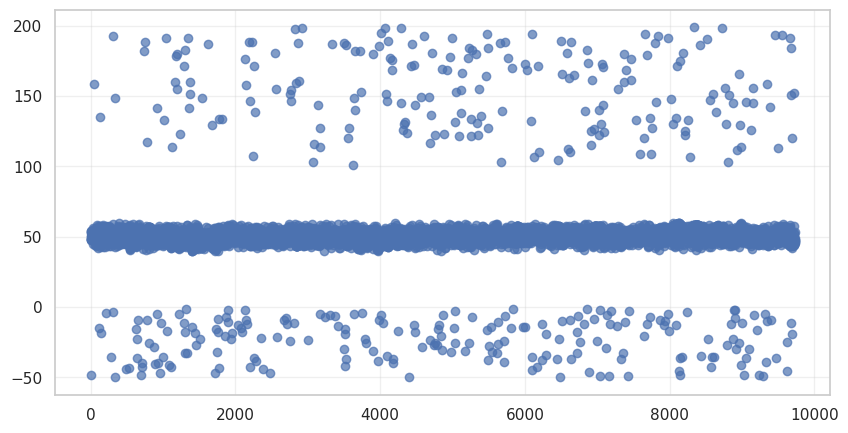

count    7824.000000
mean       51.666240
std        21.657642
min       -49.870000
25%        47.647500
50%        51.390000
75%        53.850000
max       198.900000
Name: Humidity, dtype: float64

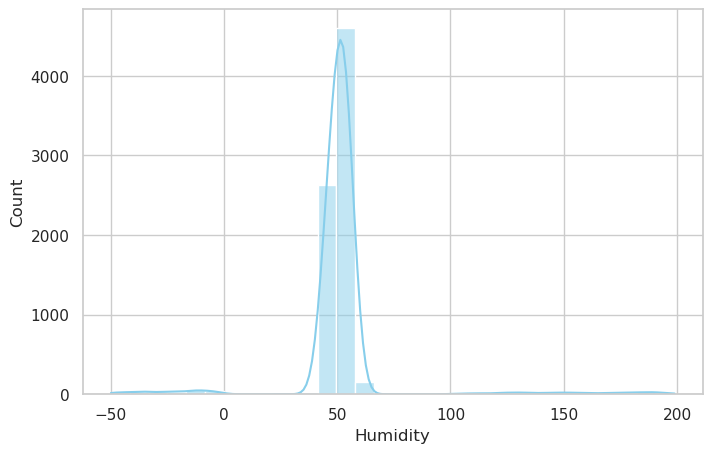

In [35]:
# Visualise and show distribution of humidity readings
plot_scatter(df["Humidity"])
plot_distribution("Humidity")
df["Humidity"].describe()

## Values above 100 and below 0 are impossible for humidity as it is in percentage

In [36]:
# inspect abnormal values
high_humidity, low_humidity = df[df["Humidity"] > 100], df[df["Humidity"] < 0]
display(high_humidity)
display(low_humidity)

,Time of Day,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID,HVAC Operation Mode,Ambient Light Level,Activity Level
50,afternoon,20.19,158.33,89.470910,620.364794,405.071346,747.384712,698.477480,621.003407,1.0,7241,heating_active,None,low_activity
128,evening,22.73,135.21,125.466163,591.519617,414.920829,714.063935,660.222162,578.452856,3.0,7241,heating_active,very_bright,low_activity
309,afternoon,18.68,192.46,26.202984,623.638405,537.465098,780.278360,737.500823,676.594185,1.0,3856,maintenance_mode,bright,moderate_activity
341,afternoon,19.24,148.53,98.191103,607.639676,488.859224,746.573065,703.077362,629.245469,1.0,3856,off,bright,moderate_activity
741,night,20.51,181.96,142.791934,565.098655,349.568283,688.618842,627.208124,557.003469,2.0,3074,eco_mode,bright,low_activity
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9662,afternoon,16.83,191.04,54.203088,570.610246,611.644836,804.217467,758.467736,719.845261,0.0,9241,eco_mode,very_bright,moderate_activity
9670,afternoon,16.54,150.68,58.544178,576.848044,595.096828,799.202805,766.820426,730.664771,0.0,9241,ventilation_only,None,moderate_activity
9679,afternoon,18.67,183.84,180.176445,572.653896,563.034853,781.939704,728.174809,697.167548,0.0,2586,maintenance_mode,very_bright,low_activity
9686,afternoon,20.84,120.33,68.815941,566.245679,484.518300,754.121435,708.360447,666.830387,1.0,2586,off,very_bright,low_activity


,Time of Day,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID,HVAC Operation Mode,Ambient Light Level,Activity Level
9,night,19.81,-48.34,8.964022,595.833260,464.828130,737.958044,687.714744,622.836602,NaN,2105,ventilation_only,None,low_activity
120,night,18.57,-14.79,121.184923,579.703970,468.239926,NaN,678.065464,620.466497,1.0,2679,cooling_active,very_bright,moderate_activity
146,night,19.69,-18.73,120.017584,549.422635,459.086470,692.412305,645.741758,571.745341,2.0,7058,off,bright,low_activity
214,night,19.67,-4.01,235.217715,600.656020,473.844566,729.094245,686.763442,606.800807,2.0,7241,eco_mode,very_bright,low_activity
282,morning,20.09,-35.48,94.681893,608.264815,511.404061,759.890965,714.800339,647.422277,1.0,3856,maintenance_mode,very_bright,moderate_activity
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9466,evening,24.49,-35.95,106.738885,553.711993,467.120371,738.711267,678.384560,621.634313,1.0,9241,heating_active,dim,low_activity
9619,afternoon,22.98,-45.32,111.177339,554.580464,480.013102,712.997190,676.412529,600.738046,1.0,7058,off,very_bright,low_activity
9622,morning,19.79,-25.05,95.602012,558.264351,512.290791,749.353012,688.354736,629.604927,2.0,9241,eco_mode,very_bright,high_activity
9682,afternoon,19.09,-11.60,73.710835,572.395364,548.852905,781.012720,743.040666,680.972017,0.0,2586,eco_mode,bright,moderate_activity


## High humidity values

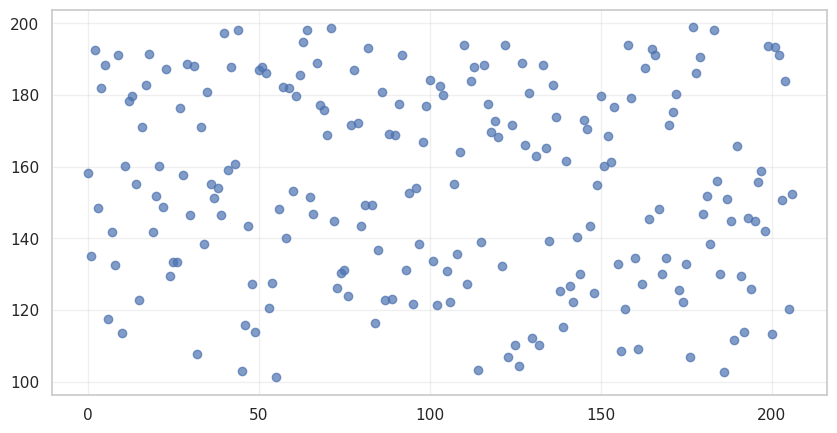

count    207.000000
mean     154.671304
std       27.304371
min      101.260000
25%      131.270000
50%      154.110000
75%      179.930000
max      198.900000
Name: Humidity, dtype: float64

Value counts for: Time of Day
Time of Day
afternoon    63
evening      53
night        53
morning      38
Name: count, dtype: int64

Value counts for: CO_GasSensor
CO_GasSensor
1.0    90
2.0    68
0.0    24
NaN    17
3.0     6
4.0     2
Name: count, dtype: int64

Value counts for: HVAC Operation Mode
HVAC Operation Mode
ventilation_only    41
cooling_active      39
off                 36
maintenance_mode    34
heating_active      31
eco_mode            26
Name: count, dtype: int64

Value counts for: Ambient Light Level
Ambient Light Level
very_bright    75
bright         52
moderate       34
dim            20
None           19
very_dim        7
Name: count, dtype: int64

Value counts for: Activity Level
Activity Level
low_activity         128
moderate_activity     59
high_activity         20
Name:

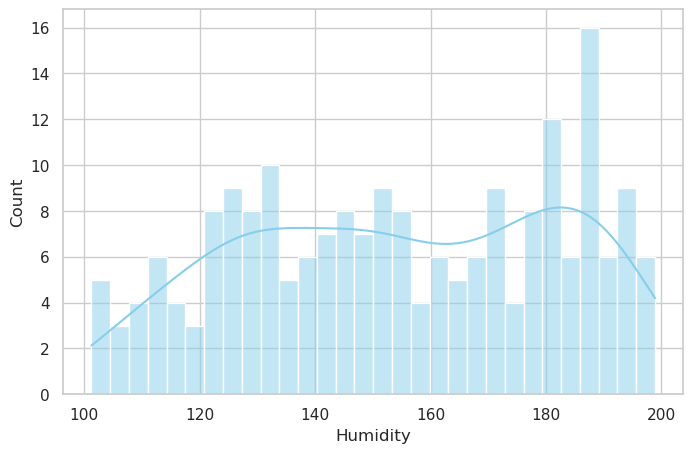

In [37]:
plot_scatter(high_humidity["Humidity"])
plot_distribution("Humidity", df=high_humidity)
print(high_humidity["Humidity"].describe())
print(show_value_counts(None, df = high_humidity))

## Low humidity values

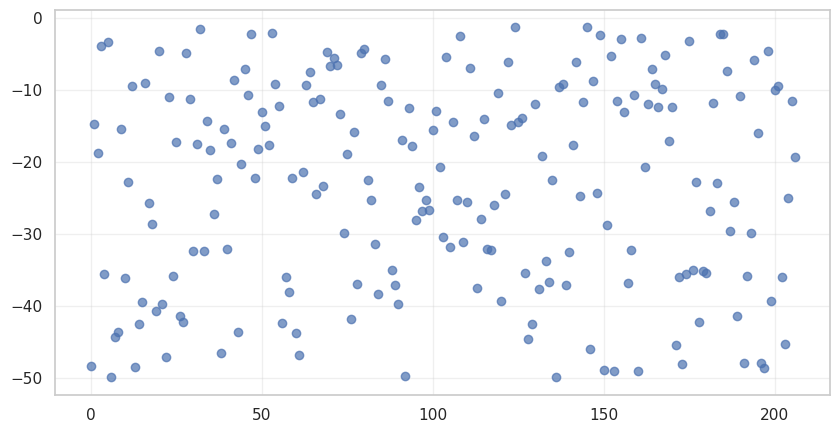

count    207.000000
mean     -23.072222
std       14.263025
min      -49.870000
25%      -35.680000
50%      -22.190000
75%      -10.975000
max       -1.350000
Name: Humidity, dtype: float64

Value counts for: Time of Day
Time of Day
afternoon    54
morning      52
night        51
evening      50
Name: count, dtype: int64

Value counts for: CO_GasSensor
CO_GasSensor
1.0    102
2.0     55
0.0     23
NaN     19
3.0      5
4.0      3
Name: count, dtype: int64

Value counts for: HVAC Operation Mode
HVAC Operation Mode
cooling_active      44
off                 37
maintenance_mode    36
heating_active      32
eco_mode            31
ventilation_only    27
Name: count, dtype: int64

Value counts for: Ambient Light Level
Ambient Light Level
very_bright    71
bright         54
moderate       29
None           20
dim            20
very_dim       13
Name: count, dtype: int64

Value counts for: Activity Level
Activity Level
low_activity         134
moderate_activity     55
high_activity         18

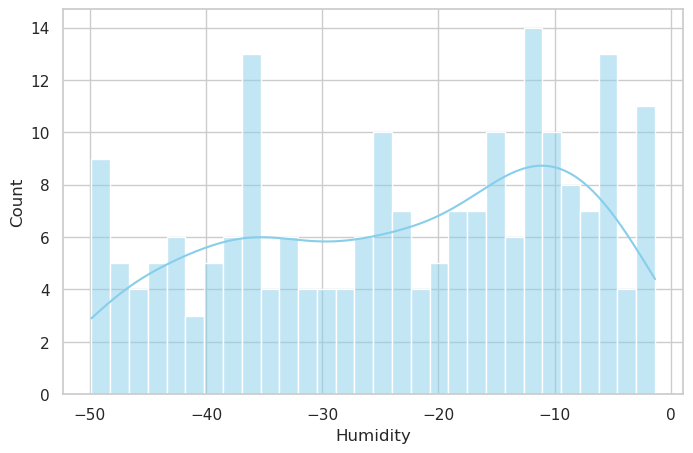

In [38]:
plot_scatter(low_humidity["Humidity"])
plot_distribution("Humidity", df=low_humidity)
print(low_humidity["Humidity"].describe())
print(show_value_counts(None, df = low_humidity))

## Normal humidity values

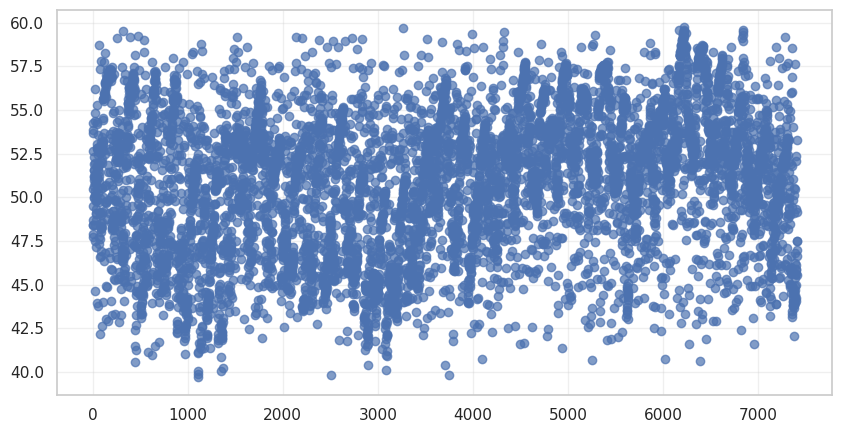

count    7410.000000
mean       50.876606
std         3.969641
min        39.690000
25%        47.900000
50%        51.390000
75%        53.697500
max        59.730000
Name: Humidity, dtype: float64

Value counts for: Time of Day
Time of Day
afternoon    1927
evening      1853
night        1816
morning      1814
Name: count, dtype: int64

Value counts for: CO_GasSensor
CO_GasSensor
1.0    3489
2.0    2032
0.0     869
NaN     636
3.0     332
4.0      52
Name: count, dtype: int64

Value counts for: HVAC Operation Mode
HVAC Operation Mode
maintenance_mode    1274
cooling_active      1274
off                 1241
heating_active      1240
eco_mode            1208
ventilation_only    1173
Name: count, dtype: int64

Value counts for: Ambient Light Level
Ambient Light Level
very_bright    2505
bright         2011
moderate       1055
None            812
dim             632
very_dim        395
Name: count, dtype: int64

Value counts for: Activity Level
Activity Level
low_activity         4237
mo

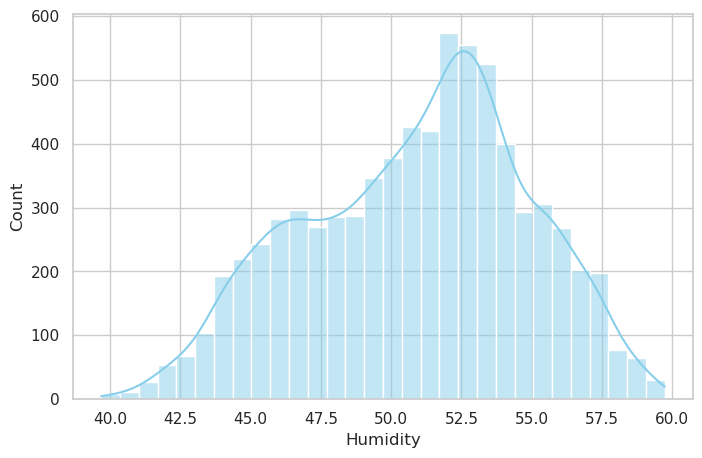

In [39]:
normal_humidity = df[(df["Humidity"] < 100) & (df["Humidity"] > 0)]
plot_scatter(normal_humidity["Humidity"])
plot_distribution("Humidity", df=normal_humidity)
print(normal_humidity["Humidity"].describe())
print(show_value_counts(None, df = normal_humidity))

## It appears that the outlier humidity values are completely random and will be removed

In [40]:
# Remove outliers by setting them to NaN
df.loc[(df["Humidity"] > 100) | (df["Humidity"] < 0), "Humidity"] = np.nan

# CO2_InfraredSensor Column

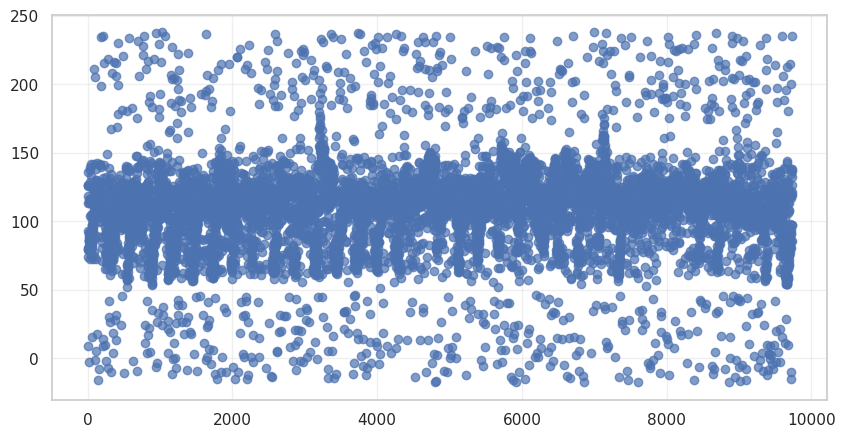

count    9735.000000
mean      109.838539
std        34.088211
min       -17.472184
25%        96.492723
50%       112.815058
75%       124.563132
max       237.873938
Name: CO2_InfraredSensor, dtype: float64

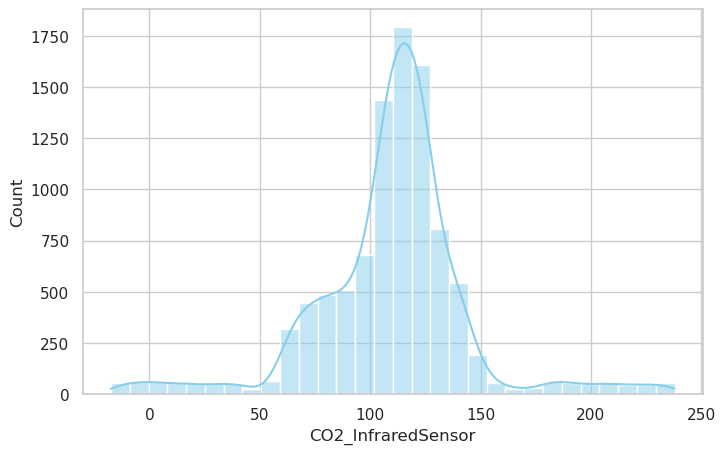

In [41]:
plot_scatter(df["CO2_InfraredSensor"])
plot_distribution("CO2_InfraredSensor")
df["CO2_InfraredSensor"].describe()

In [42]:
df[df["CO2_InfraredSensor"] < 0]

,Time of Day,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID,HVAC Operation Mode,Ambient Light Level,Activity Level
23,morning,19.25,54.37,-2.548722,574.748934,496.938842,NaN,701.422404,638.826368,NaN,1826,ventilation_only,very_bright,moderate_activity
101,evening,24.94,46.56,-1.146669,605.868070,475.340247,726.618627,681.717422,598.765948,1.0,7241,off,moderate,moderate_activity
143,morning,19.54,55.70,-16.122085,562.727918,475.855521,738.540879,691.220608,634.500030,1.0,2847,cooling_active,bright,moderate_activity
160,night,20.78,55.78,-8.084647,597.651655,430.148669,726.024078,666.731100,594.049443,3.0,7241,cooling_active,very_bright,low_activity
248,morning,19.17,50.12,-2.243409,599.983418,487.755690,756.019472,713.899773,641.651944,2.0,7241,heating_active,dim,moderate_activity
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9467,evening,24.13,49.03,-7.799714,556.177039,448.111058,733.198560,693.212051,617.778386,1.0,9241,eco_mode,very_bright,low_activity
9510,night,22.04,50.83,-2.313956,558.264765,471.607748,746.491797,697.488355,636.470082,1.0,9241,eco_mode,very_bright,low_activity
9561,morning,18.13,46.19,-2.526394,626.506239,592.704450,NaN,761.201431,714.374555,0.0,1482,ventilation_only,moderate,high_activity
9711,night,20.99,57.61,-9.992761,561.460188,446.620844,703.945003,663.041519,578.163559,1.0,4761,maintenance_mode,None,low_activity


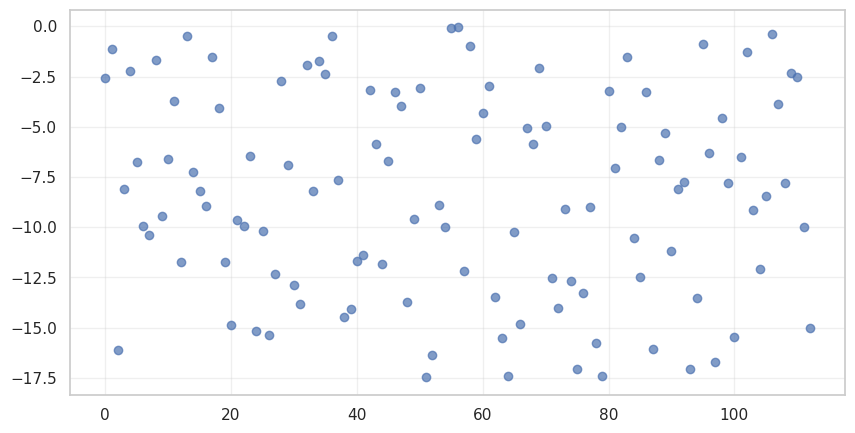


Value counts for: Time of Day
Time of Day
afternoon    36
evening      29
night        27
morning      21
Name: count, dtype: int64

Value counts for: CO_GasSensor
CO_GasSensor
1.0    55
2.0    32
NaN    12
0.0    11
3.0     3
Name: count, dtype: int64

Value counts for: HVAC Operation Mode
HVAC Operation Mode
cooling_active      22
maintenance_mode    22
ventilation_only    21
heating_active      19
off                 17
eco_mode            12
Name: count, dtype: int64

Value counts for: Ambient Light Level
Ambient Light Level
very_bright    39
bright         21
moderate       19
None           16
dim             9
very_dim        9
Name: count, dtype: int64

Value counts for: Activity Level
Activity Level
low_activity         63
moderate_activity    39
high_activity        11
Name: count, dtype: int64


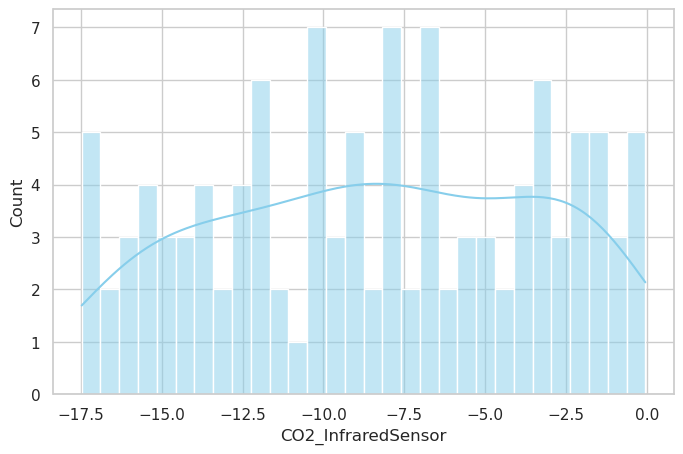

In [43]:
plot_scatter(df[df["CO2_InfraredSensor"] < 0]["CO2_InfraredSensor"])
plot_distribution("CO2_InfraredSensor", df=df[df["CO2_InfraredSensor"] < 0])
show_value_counts(df["CO2_InfraredSensor"] < 0)

## Although the negative values are suspicious, they will be handled by scaling during the machine learning pipeline

# CO2_ElectroChemicalSensor Column

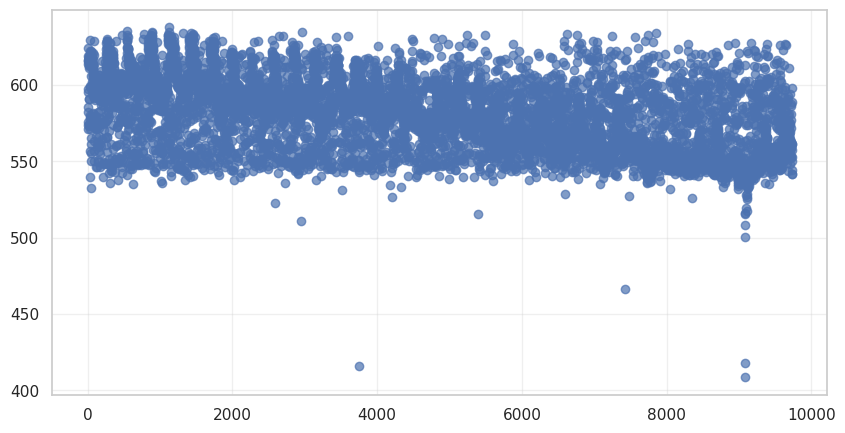

count    9735.000000
mean      578.624225
std        22.587891
min       408.599386
25%       559.336038
50%       579.351176
75%       595.578474
max       637.895790
Name: CO2_ElectroChemicalSensor, dtype: float64

In [44]:
plot_scatter(df["CO2_ElectroChemicalSensor"])
df["CO2_ElectroChemicalSensor"].describe()

## Besides a few outlier values, the data here appears to be consistent

# MetalOxideSensor_Unit1 Column

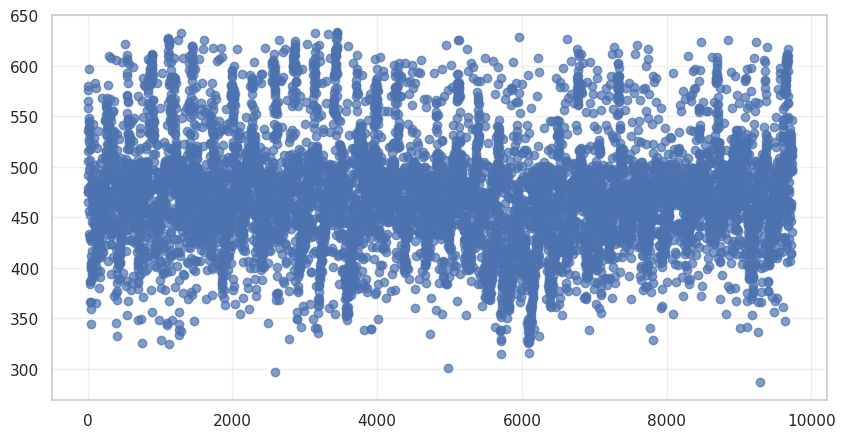

count    9735.000000
mean      471.025216
std        51.454466
min       286.825662
25%       440.268421
50%       469.244105
75%       494.765605
max       632.891693
Name: MetalOxideSensor_Unit1, dtype: float64

In [45]:
plot_scatter(df["MetalOxideSensor_Unit1"])
df["MetalOxideSensor_Unit1"].describe()

## The data here appears consistent

# MetalOxideSensor_Unit2 Column

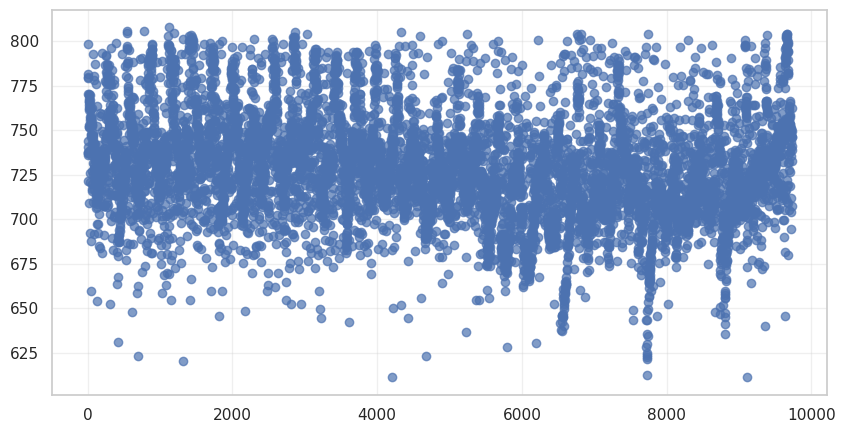

count    8333.000000
mean      728.408947
std        29.154791
min       611.168916
25%       709.678072
50%       726.784531
75%       745.033909
max       807.732943
Name: MetalOxideSensor_Unit2, dtype: float64

In [46]:
plot_scatter(df["MetalOxideSensor_Unit2"])
df["MetalOxideSensor_Unit2"].describe()

## The data here appears consistent

# MetalOxideSensor_Unit3 Column

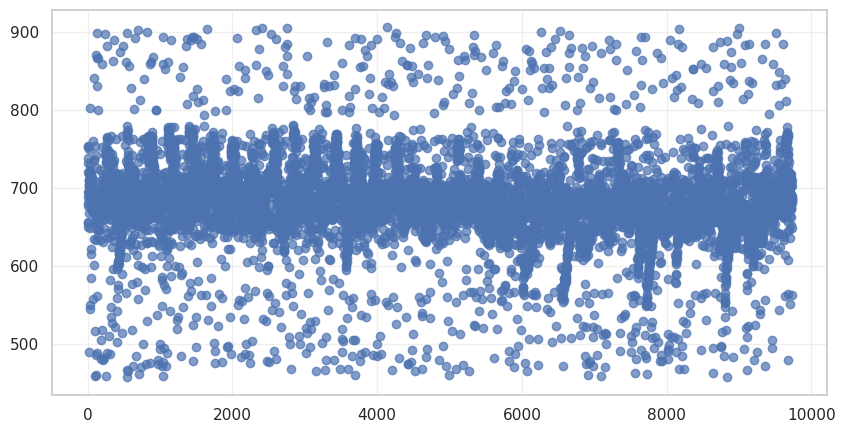

count    9735.000000
mean      680.487947
std        56.361618
min       456.673900
25%       658.474815
50%       679.847421
75%       703.680497
max       906.213097
Name: MetalOxideSensor_Unit3, dtype: float64

In [47]:
plot_scatter(df["MetalOxideSensor_Unit3"])
df["MetalOxideSensor_Unit3"].describe()

## The data here appears consistent

# MetalOxideSensor_Unit4 Column

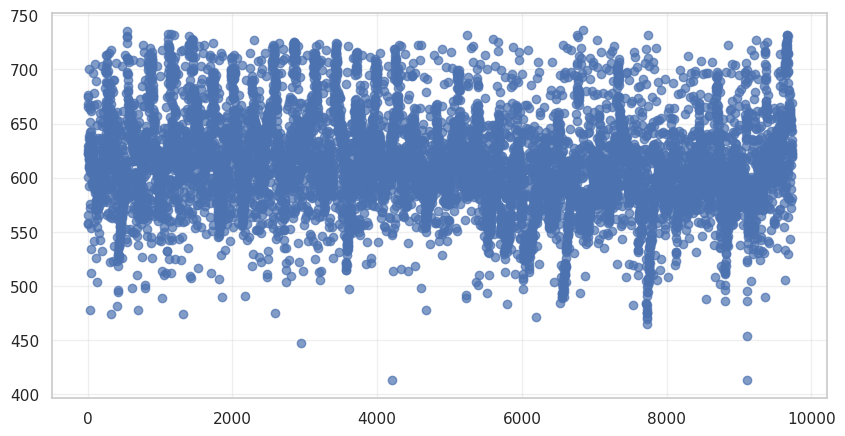

count    9735.000000
mean      612.264375
std        43.166075
min       412.791904
25%       585.367474
50%       609.514533
75%       636.161382
max       736.112361
Name: MetalOxideSensor_Unit4, dtype: float64

In [48]:
plot_scatter(df["MetalOxideSensor_Unit4"])
df["MetalOxideSensor_Unit4"].describe()

## The data here appears consistent

# CO_GasSensor Column

## Converting values here to string as data is categorical and not numerical

In [49]:
df["CO_GasSensor"] = df["CO_GasSensor"].apply(lambda x: str(x) if not pd.isna(x) else x)

In [50]:
df["CO_GasSensor"].value_counts(dropna=False)

CO_GasSensor
1.0    4582
2.0    2676
0.0    1158
NaN     829
3.0     420
4.0      70
Name: count, dtype: int64

## Besides the missing values, the rest of the data appears fine

# Session ID Column

In [51]:
df["Session ID"].value_counts()

Session ID
6528    379
4703    375
3418    356
1374    350
5820    349
7058    336
3592    335
2105    335
2847    330
3856    326
8936    304
7395    299
1903    297
4507    291
1826    275
9385    272
2679    269
9658    259
4129    253
5693    246
9127    242
8052    237
7241    237
6431    237
9184    234
9241    232
3074    230
7963    225
8374    207
6817    192
5172    191
1458    175
4761    174
6847    170
5214    165
1482    156
8649    139
2586     56
Name: count, dtype: int64

## Converting session id values to string as data is categorical instead of numerical

In [52]:
df["Session ID"] = df["Session ID"].apply(lambda x: str(x) if not pd.isna(x) else x)

# HVAC Operation Mode Column

In [53]:
df["HVAC Operation Mode"].value_counts()

HVAC Operation Mode
cooling_active      1683
maintenance_mode    1656
eco_mode            1623
off                 1613
heating_active      1613
ventilation_only    1547
Name: count, dtype: int64

## Data values here appear consistent

# Ambient Light Level Column

In [54]:
df["Ambient Light Level"].value_counts(dropna=False)

Ambient Light Level
very_bright    3287
bright         2626
moderate       1416
None           1050
dim             843
very_dim        513
Name: count, dtype: int64

## Data here is fine except for some missing values

In [55]:
df[df["Ambient Light Level"].isna()]["Time of Day"].value_counts()

Time of Day
afternoon    287
morning      271
evening      251
night        241
Name: count, dtype: int64

## Missing values do not seem to be because of sunlight and are spread evenly throughout the day

# Activity Level Column

In [56]:
df["Activity Level"].value_counts()

Activity Level
low_activity         5610
moderate_activity    3060
high_activity        1065
Name: count, dtype: int64

## There is a large difference in the amount of data for each activity level and steps must be taken to address this during model development

# Identifying association between variables using rows with no missing data

In [57]:
# create a dataframe without any missing values
valid_df = df.copy().dropna()

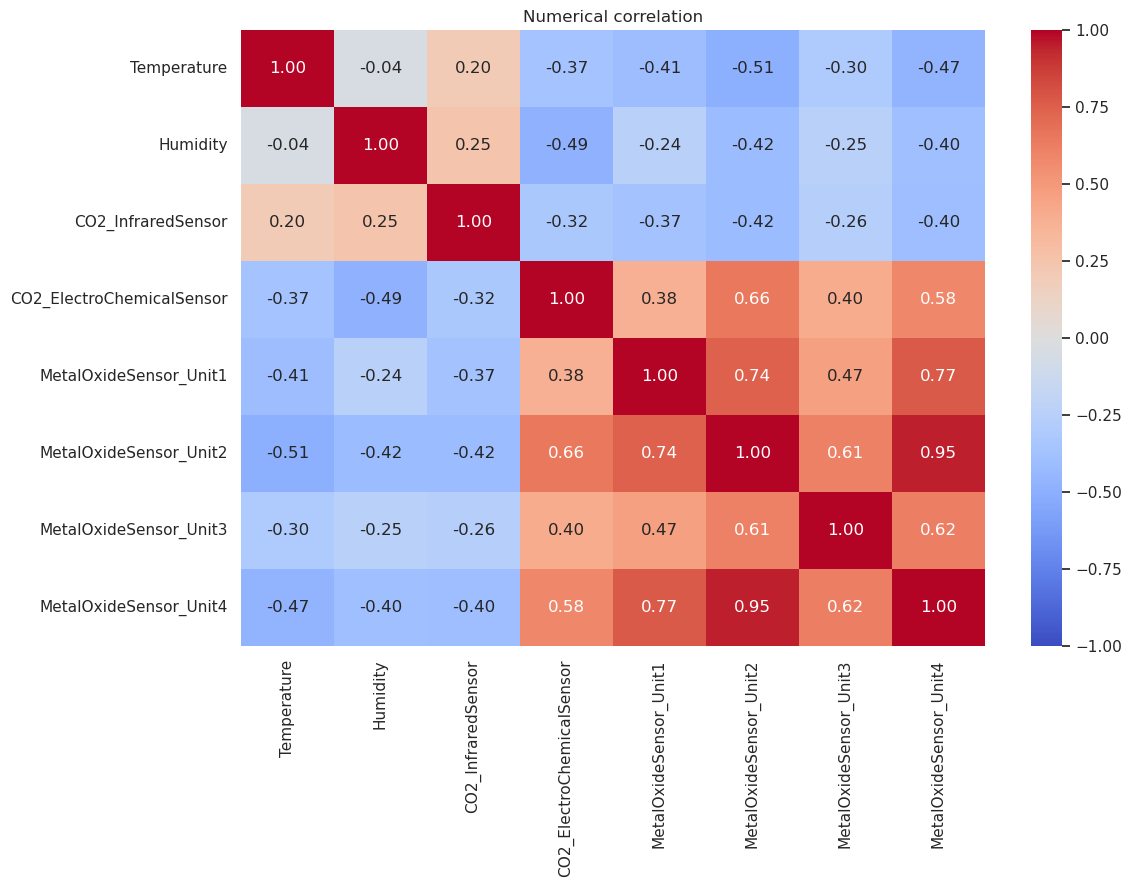

In [58]:
# calculate correlation between columns with numeric data
numeric_corr = valid_df.corr(numeric_only=True)

# visualise correlation
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_corr, annot=True, fmt="0.2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Numerical correlation")
plt.show()

## Numerical data is highly correlated except for temperature and humidity which is almost zero

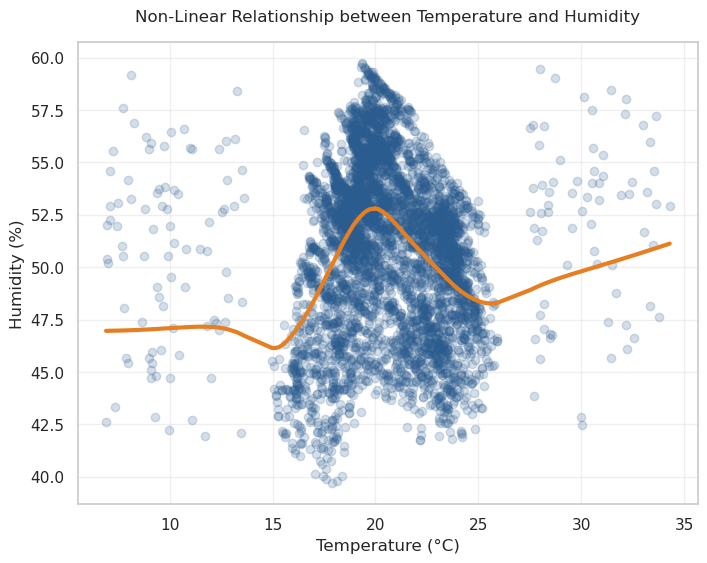

In [59]:
plt.figure(figsize=(8, 6))

# A scatter plot with a non-linear trend line
sns.regplot(
    data=valid_df, 
    x="Temperature", 
    y="Humidity", 
    scatter_kws={"alpha": 0.2, "color": "#2b5c8f"}, 
    line_kws={"color": "#e67e22", "lw": 3},
    lowess=True  # Tells seaborn to follow the local curve rather than force a straight line
)

plt.title("Non-Linear Relationship between Temperature and Humidity", fontsize=12, pad=15)
plt.xlabel("Temperature (°C)")
plt.ylabel("Humidity (%)")
plt.grid(True, alpha=0.3)
plt.show()

## Upon further analysis, the relationship between temperature and humidity is non-linear which suggests that linear machine learning models may be less effective in this scenario

In [60]:
numerical_columns = [
    "Temperature",
    "Humidity",
    "CO2_InfraredSensor",
    "CO2_ElectroChemicalSensor",
    "MetalOxideSensor_Unit1",
    "MetalOxideSensor_Unit2",
    "MetalOxideSensor_Unit3",
    "MetalOxideSensor_Unit4"
]

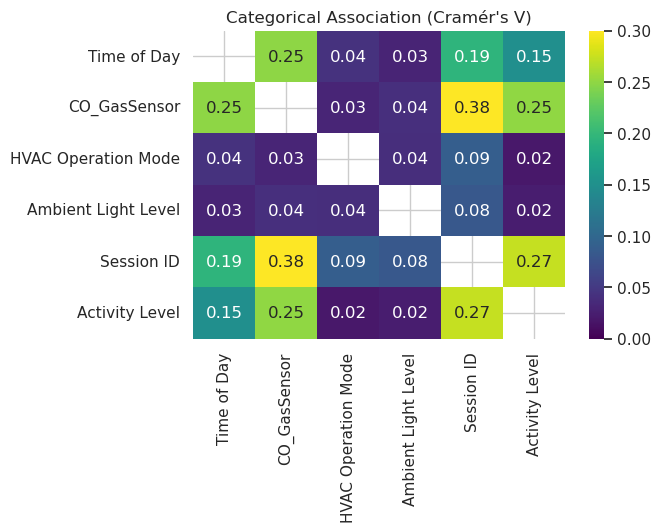

In [61]:
from scipy.stats import chi2_contingency

# function for calculating association between categorical data
def cramers_v(x, y):
    table = pd.crosstab(x, y)
    chi2 = chi2_contingency(table)[0]
    n = table.sum().sum()
    r, k = table.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

# identify columns with categorical data
categorical_columns = ["Time of Day", "CO_GasSensor", "HVAC Operation Mode", "Ambient Light Level", "Session ID", "Activity Level"]

#create matrix
matrix = pd.DataFrame(index=categorical_columns, columns=categorical_columns)

# iterate and calculate association between the columns
for col1 in categorical_columns:
    for col2 in categorical_columns:
        matrix.loc[col1, col2] = cramers_v(valid_df[col1], valid_df[col2])

association = matrix.astype(float)

# interpreting results: <0.10 = low association, <0.30 = moderate association, >0.30 = high association
plt.figure(figsize=(6, 4))
mask = np.eye(len(categorical_columns), dtype=bool)
sns.heatmap(association, annot=True, fmt=".2f", cmap="viridis", vmin=0, vmax=0.3, mask=mask)
plt.title("Categorical Association (Cramér's V)")
plt.show()

### interpreting results: <0.10 = low association, <0.30 = moderate association, >0.30 = high association

## It appears that the HVAC operation mode and ambient light level have almost no impact on activity level

In [62]:
def eta_squared(categories, values):
    # Combine data to guarantee matching indices and drop missing rows automatically 
    df = pd.DataFrame({'cat': categories, 'val': values}).dropna()
    
    # If there are no groups or no data, variance can't be calculated
    if len(df['cat'].unique()) < 2 or len(df) == 0:
        return 0.0
        
    overall_mean = df['val'].mean()
    
    # df.groupby('cat')['val'] yields the separate numerical slices for each group
    ss_between = sum(
        len(group) * (group.mean() - overall_mean) ** 2
        for _, group in df.groupby('cat')['val']
    )
    
    # total sum of squares
    ss_total = sum((df['val'] - overall_mean) ** 2)
    # Guard against division by zero if all values in the dataset are identical
    if ss_total == 0:
        return 0.0

    return ss_between / ss_total

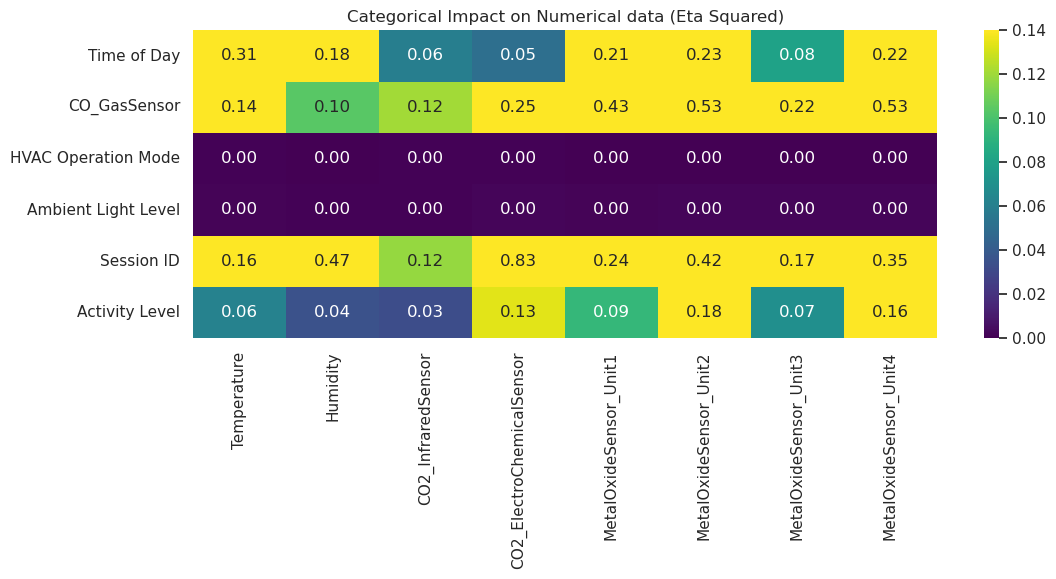

In [63]:
results = pd.DataFrame(index=categorical_columns, columns=numerical_columns)

for cat in categorical_columns:
    for num in numerical_columns:
        results.loc[cat, num] = eta_squared(
            valid_df[cat],
            valid_df[num]
        )

results = results.astype(float)

# interpreting results: 0.01 = small effect, 0.06 = medium effect, >0.14 high effect
plt.figure(figsize=(12, 4))
sns.heatmap(results, annot=True, fmt=".2f", cmap="viridis", vmin=0, vmax=0.14)
plt.title("Categorical Impact on Numerical data (Eta Squared)")
plt.show()

### interpreting results: 0.01 = small effect, 0.06 = medium effect, >0.14 high effect

## HVAC operation mode and ambient light level have no effect on the numerical data

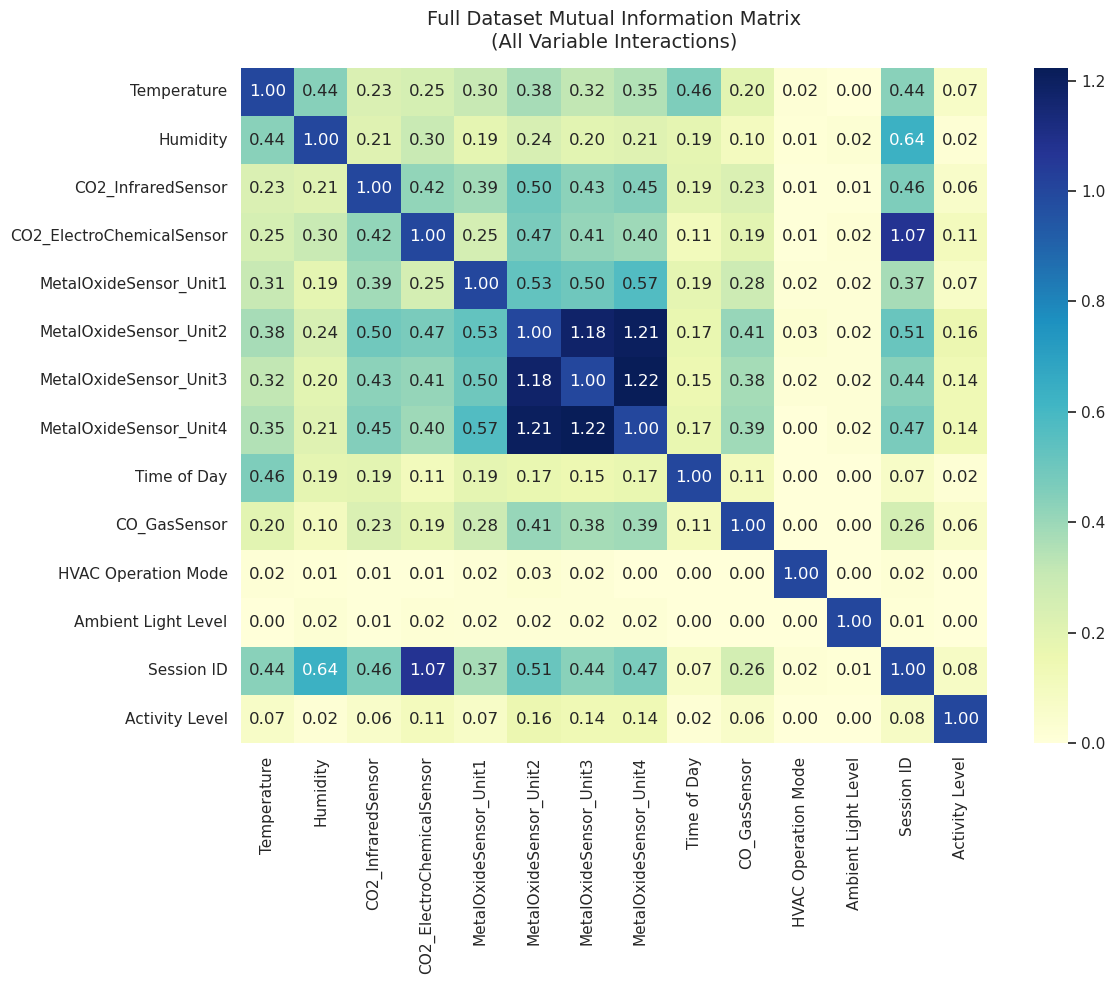

In [64]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.feature_selection import mutual_info_regression, mutual_info_classif

# Prepare data: Create a copy and encode all categorical columns to numbers
df_encoded = valid_df.copy()
encoder = OrdinalEncoder()
df_encoded[categorical_columns] = encoder.fit_transform(valid_df[categorical_columns].astype(str))

# Initialize a square matrix
all_cols = numerical_columns + categorical_columns
full_mi_matrix = pd.DataFrame(index=all_cols, columns=all_cols, dtype=float)

# Calculate MI for every pair
for col_x in all_cols:
    for col_y in all_cols:
        if col_x == col_y:
            full_mi_matrix.loc[col_x, col_y] = 1.0 # Self-MI is trivial
            continue
            
        # Determine if the target (col_y) is categorical or numerical
        if col_y in categorical_columns:
            # Categorical Target: use mutual_info_classif
            score = mutual_info_classif(
                df_encoded[[col_x]], 
                df_encoded[col_y], 
                discrete_features=(col_x in categorical_columns),
                random_state=42
            )[0]
        else:
            # Numerical Target: use mutual_info_regression
            score = mutual_info_regression(
                df_encoded[[col_x]], 
                df_encoded[col_y], 
                discrete_features=(col_x in categorical_columns),
                random_state=42
            )[0]
            
        full_mi_matrix.loc[col_x, col_y] = score

# Plot the Unified Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    full_mi_matrix, 
    annot=True, 
    fmt=".2f", 
    cmap="YlGnBu", 
    vmin=0, 
    vmax=full_mi_matrix.values[~np.eye(len(all_cols), dtype=bool)].max()
)

plt.title("Full Dataset Mutual Information Matrix\n(All Variable Interactions)", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

## Based on the analysis, HVAC Operation Mode and Ambient Light Level has no measurable relationship with Activity Level and will not be used in model training.

# Section for handling missing values. We will be using KNN imputation to fill in the missing values

Firstly, we take the subset of the original data without any rows with missing data. 
We will be identifying the optimal number of neighbours to use for imputation. 
We do this by artificially introducing missing data into clean data and imputing them with varying values of n_neighbours.
We then calculate the difference between the imputed data and the original data that was artifically removed.
n_neighbours will be selected from the results

n_neighbors  |  Avg MSE   |  Humidity MSE  
---------------------------------------------
     1       |  83.4965   |     6.2501     
     3       |  58.3974   |     5.0075     
     5       |  52.3595   |     4.9639     
     7       |  53.2946   |     5.1242     
     9       |  54.2254   |     5.3309     
     11      |  56.8506   |     5.4042     
     15      |  59.6169   |     5.6197     
     21      |  64.5460   |     5.8529     
     31      |  73.7685   |     6.2422     
     51      |  85.1185   |     6.9419     
    100      |  100.1952  |     8.0117     


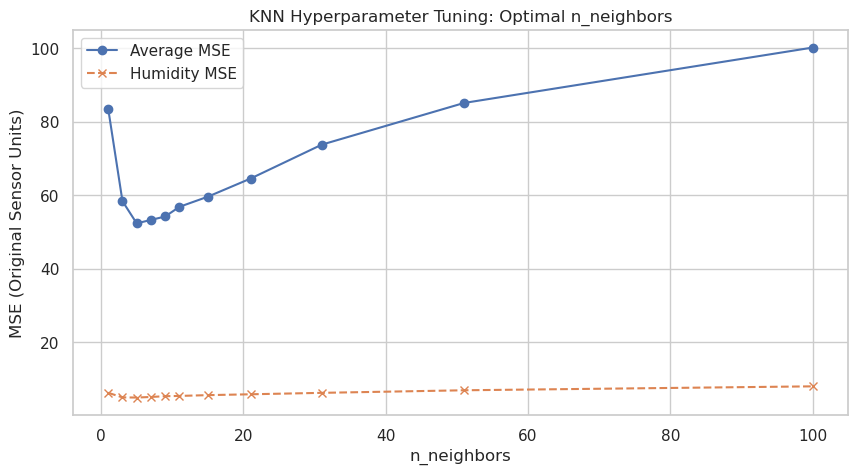

In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

# Setup: Ensure df_sim is numeric
df_sim = valid_df.copy()

# Map categoricals to integers
encoder = OrdinalEncoder()
df_sim[categorical_columns] = encoder.fit_transform(df_sim[categorical_columns].astype(str))

# Convert all columns to float to ensure consistency
df_sim = df_sim.astype(float)

# 1. Scale data: ONLY numerical columns
scaler = MinMaxScaler()
df_sim_scaled = df_sim.copy()
df_sim_scaled[numerical_columns] = scaler.fit_transform(df_sim[numerical_columns])

# 2. Setup the "Missing Data" simulation
messy_cols = ['Humidity', 'MetalOxideSensor_Unit2', 'CO_GasSensor', 'Ambient Light Level']
np.random.seed(42)
mask_dict = {}
true_values_dict = {}
df_masked = df_sim_scaled.copy()

for col in messy_cols:
    col_mask = np.random.rand(len(df_masked)) < 0.10
    mask_dict[col] = col_mask
    true_values_dict[col] = df_masked.loc[col_mask, col]
    df_masked.loc[col_mask, col] = np.nan

# 3. Optimization Loop
n_candidates = [1, 3, 5, 7, 9, 11, 15, 21, 31, 51, 100]
results = []

print(f"{'n_neighbors':^12} | {'Avg MSE':^10} | {'Humidity MSE':^15}")
print("-" * 45)

for n in n_candidates:
    # Impute
    imputer = KNNImputer(n_neighbors=n, weights='distance')
    imputed_array = imputer.fit_transform(df_masked)
    df_imputed = pd.DataFrame(imputed_array, columns=df_sim.columns)
    
    # Reverse scaling for readable units
    df_imputed_real = df_imputed.copy()
    df_imputed_real[numerical_columns] = scaler.inverse_transform(df_imputed[numerical_columns])
    
    df_true_real = df_sim.copy() # Already contains original values
    
    # Calculate errors
    col_mse_dict = {}
    for col in messy_cols:
        col_mask = mask_dict[col]
        true_vals = df_true_real.loc[col_mask, col]
        imputed_vals = df_imputed_real.loc[col_mask, col]
        col_mse_dict[col] = mean_squared_error(true_vals, imputed_vals)
    
    avg_mse = np.mean(list(col_mse_dict.values()))
    hum_mse = col_mse_dict['Humidity']
    
    print(f"{n:^12d} | {avg_mse:^10.4f} | {hum_mse:^15.4f}")
    results.append({'n': n, 'avg_mse': avg_mse, 'hum_mse': hum_mse})

# 4. Visualization
res_df = pd.DataFrame(results)
plt.figure(figsize=(10, 5))
plt.plot(res_df['n'], res_df['avg_mse'], label='Average MSE', marker='o')
plt.plot(res_df['n'], res_df['hum_mse'], label='Humidity MSE', linestyle='--', marker='x')
plt.title("KNN Hyperparameter Tuning: Optimal n_neighbors")
plt.xlabel("n_neighbors")
plt.ylabel("MSE (Original Sensor Units)")
plt.legend()
plt.grid(True)
plt.show()

## n = 5 is the optimal amount of neighbours to use

In [66]:
# Create a copy of original dataframe
df_final = df.copy()

# Encode categorical columns using the same encoder structure
# Ensure categorical_columns is defined (list of column names)
encoders = {}
for col in categorical_columns:
    encoder = OrdinalEncoder()
    # fit on non-nulls and transform to keep NaNs as NaNs for the imputer
    non_null_mask = df_final[col].notnull()
    
    # Reshape for sklearn: .values.reshape(-1, 1)
    df_final.loc[non_null_mask, col] = encoder.fit_transform(
        df_final.loc[non_null_mask, [col]]
    ).flatten()
    
    encoders[col] = encoder

# Scale numerical data
# convert to float to ensure the imputer works without type errors
df_final_numeric = df_final.astype(float)
scaler = MinMaxScaler()
df_final_scaled = df_final_numeric.copy()
df_final_scaled[numerical_columns] = scaler.fit_transform(df_final_numeric[numerical_columns])

# Impute using optimal n_neighbors
optimised_n = 5 
final_imputer = KNNImputer(n_neighbors=optimised_n, weights='distance')
imputed_array = final_imputer.fit_transform(df_final_scaled)

# Convert back to DataFrame
df_clean = pd.DataFrame(imputed_array, columns=df_final.columns)

# Reverse scaling (numerical only)
df_clean[numerical_columns] = scaler.inverse_transform(df_clean[numerical_columns])

# Reverse Encoding (categorical only)
for col in categorical_columns:
    # Round to nearest integer to get back to the encoder's mapping IDs
    df_clean[col] = df_clean[col].round().astype(int)
    # Use the specific encoder saved for this column
    df_clean[col] = encoders[col].inverse_transform(df_clean[[col]]).flatten()

## Checking results

In [67]:
df_clean.isnull().sum()

Time of Day                  0
Temperature                  0
Humidity                     0
CO2_InfraredSensor           0
CO2_ElectroChemicalSensor    0
MetalOxideSensor_Unit1       0
MetalOxideSensor_Unit2       0
MetalOxideSensor_Unit3       0
MetalOxideSensor_Unit4       0
CO_GasSensor                 0
Session ID                   0
HVAC Operation Mode          0
Ambient Light Level          0
Activity Level               0
dtype: int64

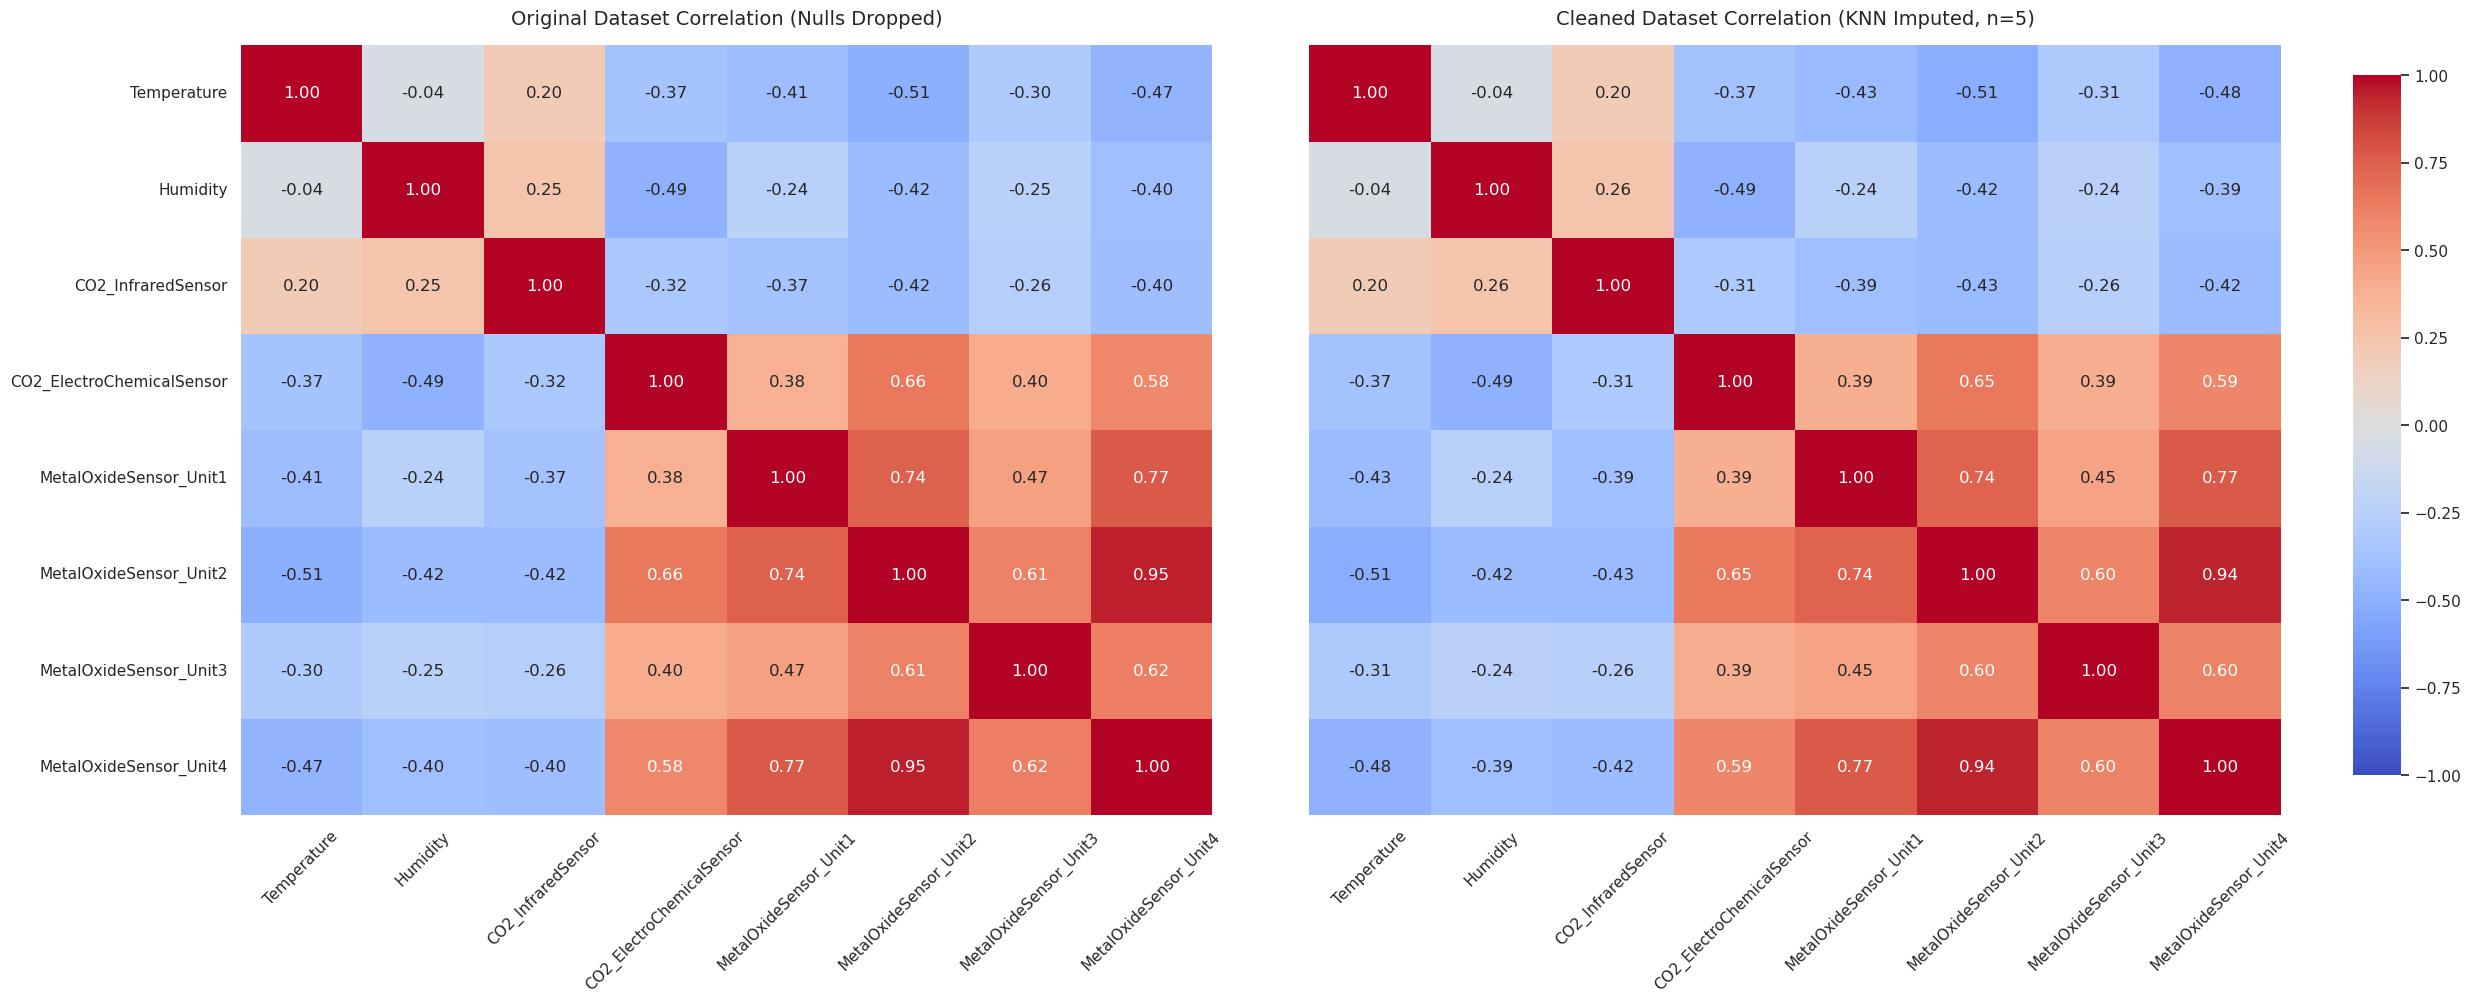

In [68]:
# calculate correlation between columns with numeric data
original_numeric_corr = valid_df.corr(numeric_only=True)
new_numeric_corr = df_clean.corr(numeric_only=True)

# create canvas
fig, axes = plt.subplots(1, 2, figsize=(24, 10), sharey=True)

# original
sns.heatmap(original_numeric_corr, annot=True, fmt="0.2f", cmap="coolwarm", vmin=-1, vmax=1, cbar=False, ax=axes[0])
axes[0].set_title("Original Dataset Correlation (Nulls Dropped)", fontsize=14, pad=15)
axes[0].tick_params(axis='x', rotation=45)

# imputed
sns.heatmap(new_numeric_corr, annot=True, fmt="0.2f", cmap="coolwarm", vmin=-1, vmax=1, cbar_ax=fig.add_axes([0.93, 0.15, 0.02, 0.7]), ax=axes[1])
axes[1].set_title(f"Cleaned Dataset Correlation (KNN Imputed, n={optimised_n})", fontsize=14, pad=15)
axes[1].tick_params(axis='x', rotation=45)

plt.subplots_adjust(wspace=0.1, left=0.05, right=0.90)
plt.show()

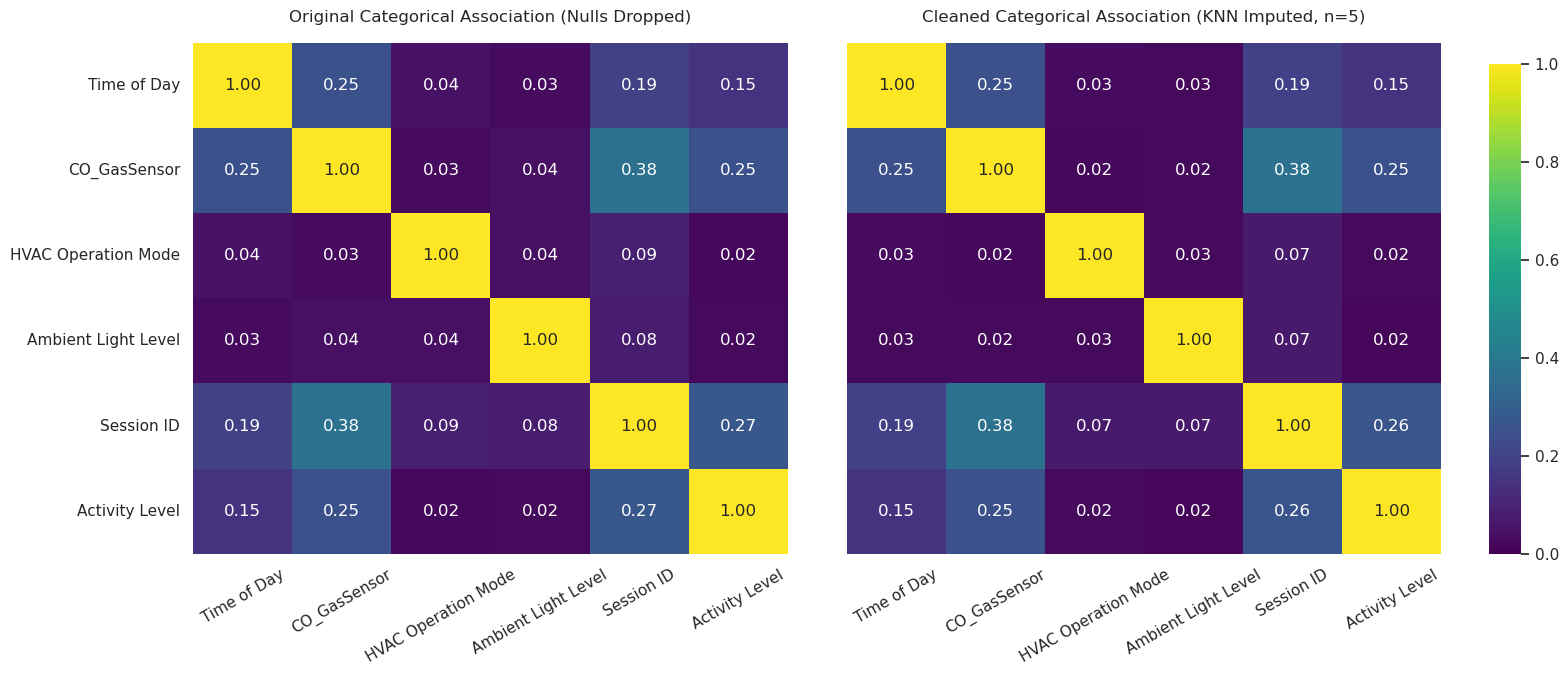

In [69]:
# create matrices for original and new data
origial_matrix = pd.DataFrame(index=categorical_columns, columns=categorical_columns)
new_matrix = pd.DataFrame(index=categorical_columns, columns=categorical_columns)

# calculate Cramér's V for both
for col1 in categorical_columns:
    for col2 in categorical_columns:
        origial_matrix.loc[col1, col2] = cramers_v(valid_df[col1], valid_df[col2])
        new_matrix.loc[col1, col2] = cramers_v(df_clean[col1], df_clean[col2])

# convert matrices to float type for plotting
original_association = origial_matrix.astype(float)
new_association = new_matrix.astype(float)

# create canvas
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

# original
sns.heatmap(original_association, annot=True, fmt=".2f", cmap="viridis", vmin=0, vmax=1.0,  cbar=False, ax=axes[0])
axes[0].set_title("Original Categorical Association (Nulls Dropped)", fontsize=12, pad=15)
axes[0].tick_params(axis='x', rotation=30)

# imputed
sns.heatmap(new_association, annot=True, fmt=".2f", cmap="viridis", vmin=0, vmax=1.0, cbar_ax=fig.add_axes([0.93, 0.15, 0.02, 0.7]), ax=axes[1])
axes[1].set_title(f"Cleaned Categorical Association (KNN Imputed, n={optimised_n})", fontsize=12, pad=15)
axes[1].tick_params(axis='x', rotation=30)

plt.subplots_adjust(wspace=0.1, left=0.12, right=0.90, bottom=0.15)
plt.show()

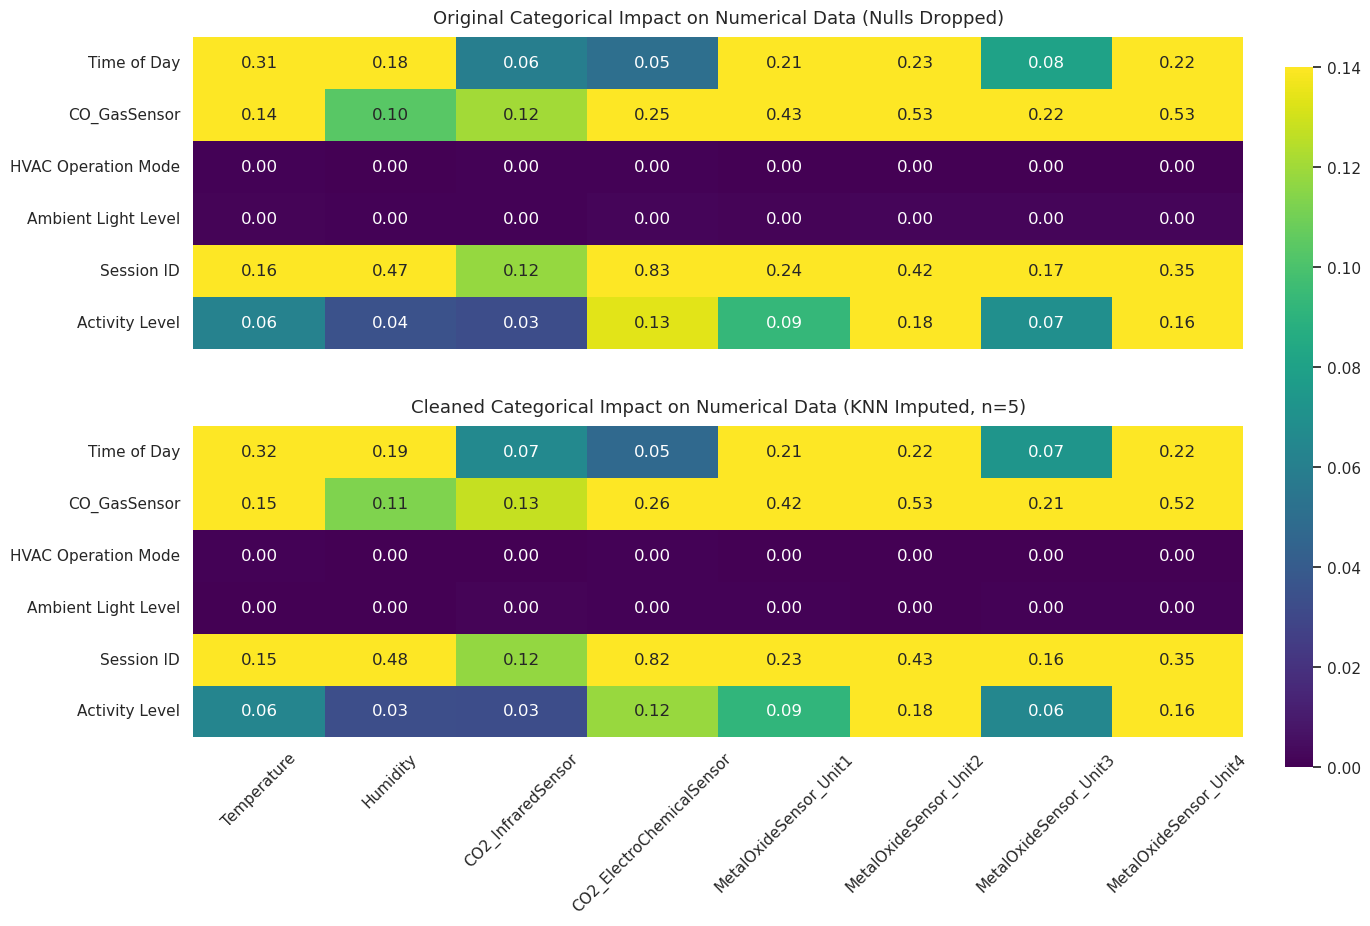

In [70]:
# create matrices for both
original_results = pd.DataFrame(index=categorical_columns, columns=numerical_columns)
new_results = pd.DataFrame(index=categorical_columns, columns=numerical_columns)

# calculate Eta Squared for both
for cat in categorical_columns:
    for num in numerical_columns:
        original_results.loc[cat, num] = eta_squared(valid_df[cat], valid_df[num])
        new_results.loc[cat, num] = eta_squared(df_clean[cat], df_clean[num])

# convert matrices to float type for plotting
original_eta = original_results.astype(float)
new_eta = new_results.astype(float)

# create canvas
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# original
sns.heatmap(original_eta, annot=True, fmt=".2f", cmap="viridis", vmin=0, vmax=0.14,cbar=False, ax=axes[0])
axes[0].set_title("Original Categorical Impact on Numerical Data (Nulls Dropped)", fontsize=13, pad=10)

# imputed
sns.heatmap(new_eta, annot=True, fmt=".2f", cmap="viridis", vmin=0, vmax=0.14, cbar_ax=fig.add_axes([0.93, 0.15, 0.02, 0.7]), ax=axes[1])
axes[1].set_title(f"Cleaned Categorical Impact on Numerical Data (KNN Imputed, n={optimised_n})", fontsize=13, pad=10)
axes[1].tick_params(axis='x', rotation=45)

plt.subplots_adjust(hspace=0.25, left=0.15, right=0.90, bottom=0.18)
plt.show()

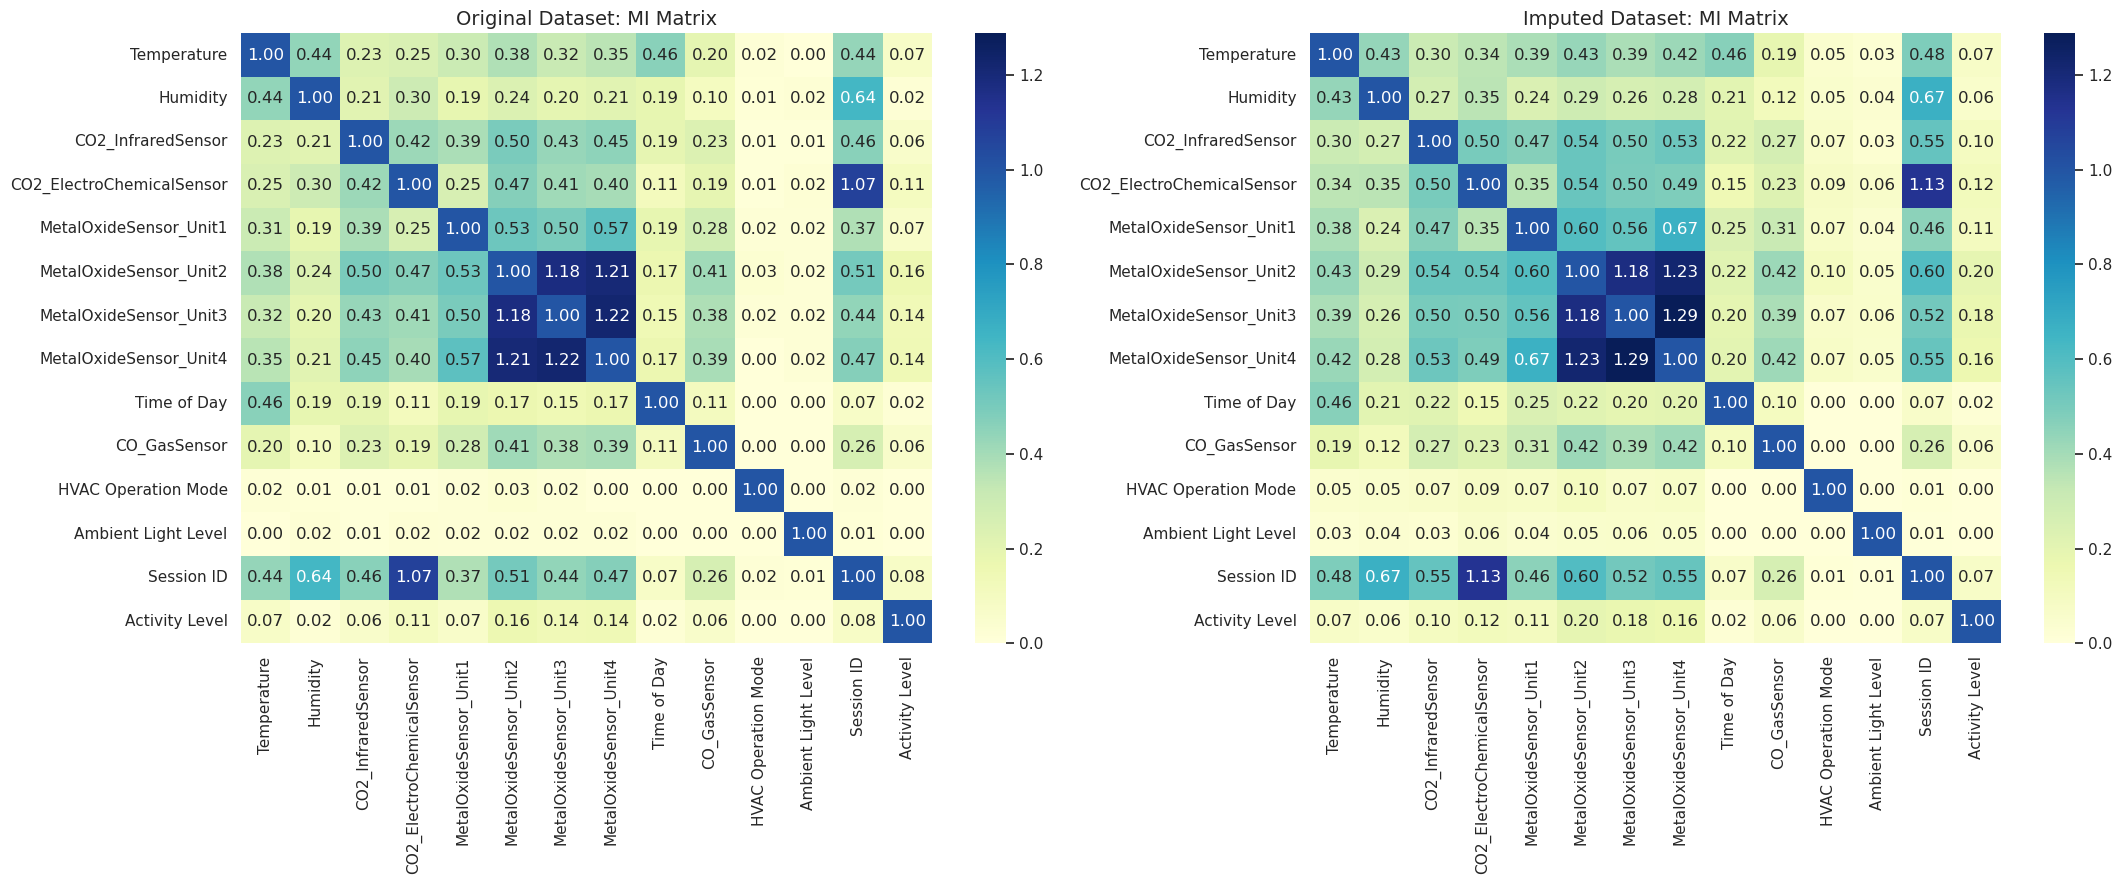

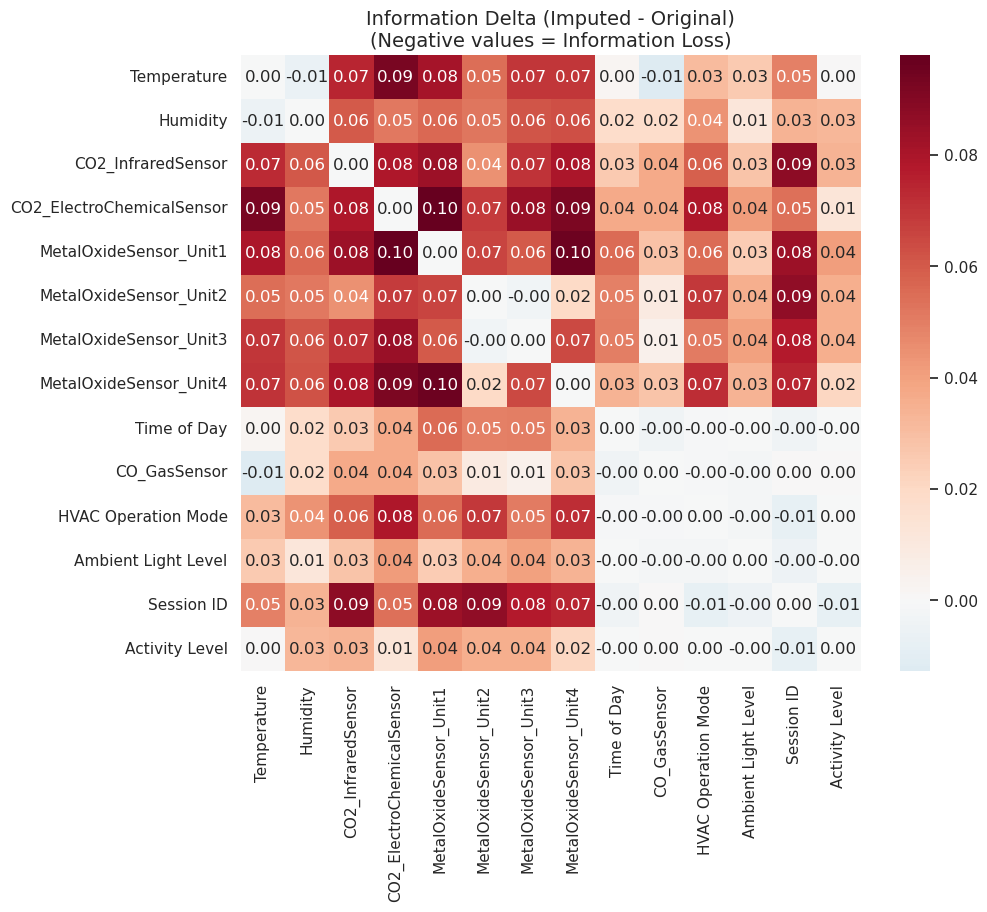

In [71]:
def compute_mi_matrix(df, numerical_cols, categorical_cols):
    """Calculates the full MI matrix for a given DataFrame."""
    # Encode categories
    df_encoded = df.copy()
    encoder = OrdinalEncoder()
    df_encoded[categorical_cols] = encoder.fit_transform(df[categorical_cols].astype(str))
    
    all_cols = numerical_cols + categorical_cols
    mi_matrix = pd.DataFrame(index=all_cols, columns=all_cols, dtype=float)
    
    for col_x in all_cols:
        for col_y in all_cols:
            if col_x == col_y:
                mi_matrix.loc[col_x, col_y] = 1.0
                continue
                
            is_x_discrete = (col_x in categorical_cols)
            
            if col_y in categorical_cols:
                score = mutual_info_classif(
                    df_encoded[[col_x]], df_encoded[col_y], 
                    discrete_features=[is_x_discrete], random_state=42
                )[0]
            else:
                score = mutual_info_regression(
                    df_encoded[[col_x]], df_encoded[col_y], 
                    discrete_features=[is_x_discrete], random_state=42
                )[0]
            mi_matrix.loc[col_x, col_y] = score
    return mi_matrix

# Compute both
mi_original = compute_mi_matrix(valid_df, numerical_columns, categorical_columns)
mi_imputed = compute_mi_matrix(df_clean, numerical_columns, categorical_columns)

# Plot side-by-side
fig, axes = plt.subplots(1, 2, figsize=(22, 9))
v_max = max(mi_original.values[~np.eye(len(mi_original), dtype=bool)].max(), 
            mi_imputed.values[~np.eye(len(mi_imputed), dtype=bool)].max())

sns.heatmap(mi_original, annot=True, fmt=".2f", cmap="YlGnBu", vmin=0, vmax=v_max, ax=axes[0])
axes[0].set_title("Original Dataset: MI Matrix", fontsize=14)

sns.heatmap(mi_imputed, annot=True, fmt=".2f", cmap="YlGnBu", vmin=0, vmax=v_max, ax=axes[1])
axes[1].set_title("Imputed Dataset: MI Matrix", fontsize=14)

plt.tight_layout()
plt.show()

# The "Delta" Matrix 
plt.figure(figsize=(10, 8))
delta_matrix = mi_imputed - mi_original
sns.heatmap(delta_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.title("Information Delta (Imputed - Original)\n(Negative values = Information Loss)", fontsize=14)
plt.show()

## After imputation, the association between the different columns changed minimally. This indicates that imputation produced results that are consistent with the original non-mising data

# Exploring Dimensionality Reduction

In [72]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Drop categorical data, keeping numeric data
df_numeric = df_clean.select_dtypes(include=[np.number])

# Scale data first
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_numeric)

# Run PCA
pca = PCA()
pca.fit(df_scaled)

# Check cumulative variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
print(cumulative_variance)

[0.53021491 0.66915222 0.76683237 0.85182108 0.92031607 0.96485959
 0.99331196 1.        ]


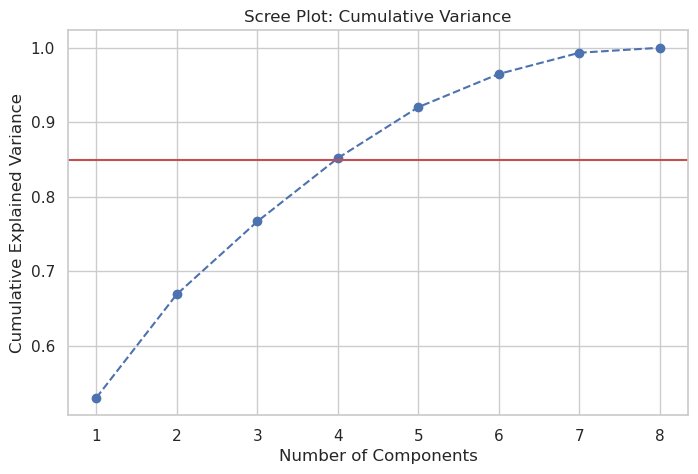

In [73]:
# Visualise cumulative variance
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Scree Plot: Cumulative Variance')
plt.grid(True)
plt.axhline(y=0.85, color='r', linestyle='-') # Horizontal line at 85%
plt.show()

## Based off the graph, the numeric data in the dataset are highly related. If the 8 numeric columns were to be reduced to a single component, 53% of the original information in those columns would remain. At 5 components, over 90% of the original information would be represented. This suggests that dimensionality reduction through principal component analysis would be effective on this dataset without removing a large amount of information

In [74]:
loadings = pd.DataFrame(
    pca.components_.T, 
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=df_numeric.columns
)

print(loadings)

                                PC1       PC2       PC3       PC4       PC5  \
Temperature                0.274783 -0.573475  0.112500  0.536464 -0.143676   
Humidity                   0.238057  0.733432  0.159039  0.091910  0.148839   
CO2_InfraredSensor         0.261758  0.147328 -0.891146  0.108501 -0.320973   
CO2_ElectroChemicalSensor -0.353173 -0.252316 -0.279787 -0.491296  0.255542   
MetalOxideSensor_Unit1    -0.386360  0.191984  0.165560  0.228331 -0.564326   
MetalOxideSensor_Unit2    -0.459184  0.038718 -0.069651  0.039127 -0.150363   
MetalOxideSensor_Unit3    -0.329323  0.075617 -0.235364  0.614776  0.632283   
MetalOxideSensor_Unit4    -0.453870  0.061333 -0.044396  0.137837 -0.219144   

                                PC6       PC7       PC8  
Temperature               -0.521021  0.048490  0.026715  
Humidity                  -0.588042  0.060974  0.001408  
CO2_InfraredSensor        -0.017678 -0.020503  0.010369  
CO2_ElectroChemicalSensor -0.576630 -0.299091 -0.068513 

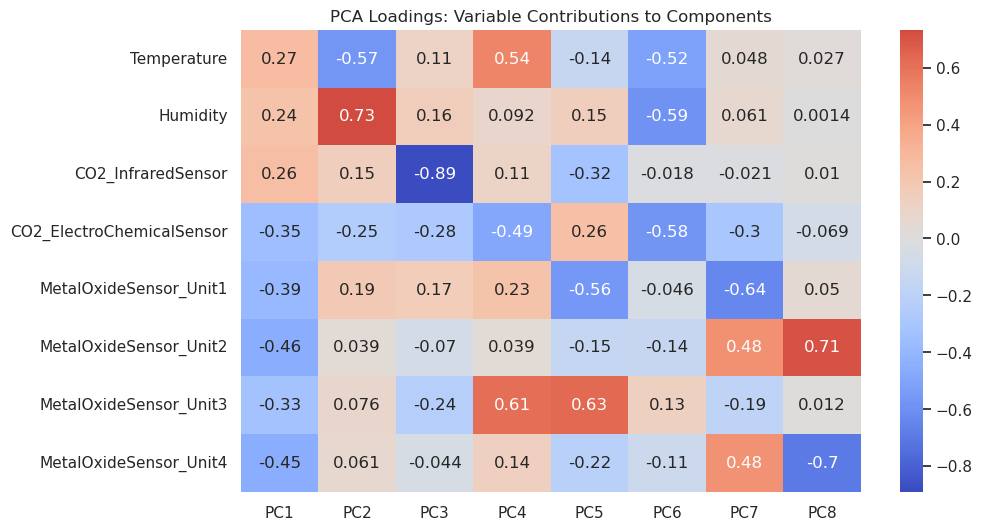

In [75]:
plt.figure(figsize=(10, 6))
sns.heatmap(loadings, annot=True, cmap='coolwarm', center=0)
plt.title("PCA Loadings: Variable Contributions to Components")
plt.show()

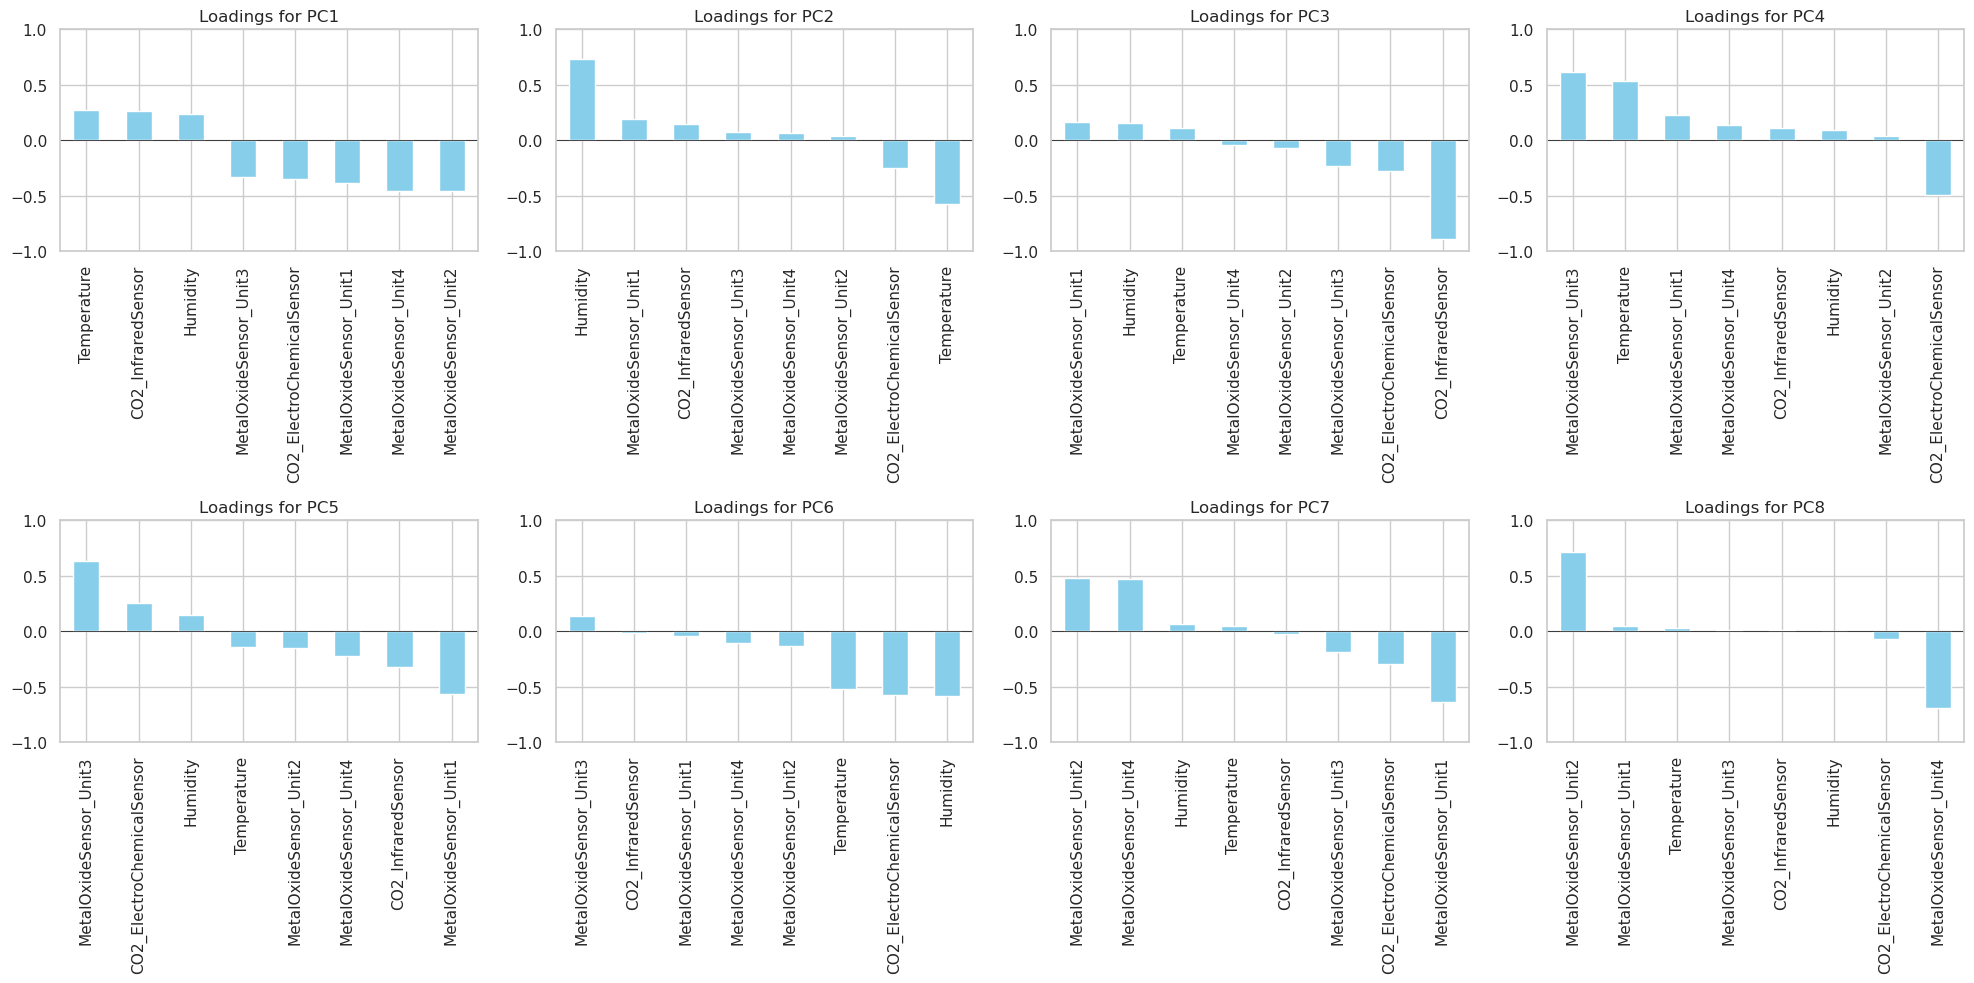

In [76]:
# Create a figure with a 2x4 grid of subplots (for 8 components)
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))
axes = axes.flatten()  # Flatten to make it easy to iterate over

# Iterate through each component and plot its loadings
for i in range(8):
    component_name = f'PC{i+1}'
    # Sort values for visual clarity
    loadings[component_name].sort_values(ascending=False).plot(kind='bar', ax=axes[i], color='skyblue')
    axes[i].set_title(f'Loadings for {component_name}')
    axes[i].set_ylim(-1, 1)  # Keeps the scale consistent for all plots
    axes[i].axhline(0, color='black', linewidth=0.5) # Add a baseline

plt.tight_layout()
plt.show()

## The data also suggest that metal oxide sensor data are the biggest contributors to variance

# Simple model training

## This class was taken from our pipeline

In [77]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

target_col = "Activity Level"
class DataPreprocessor:
    def __init__(self):
        self.target_col = target_col
        self.pipeline = None

    def _auto_identify_features(self, df):
        """
        Automatically identify data types of columns in a dataframe

        Args:
            df (str): The dataframe to be checked
        """
        # Drop the target from the dataframe to identify only features
        features = df.drop(columns=[self.target_col])
        
        # Automatically identify numeric columns (float, int)
        self.numeric_features = features.select_dtypes(include=['int64', 'float64']).columns.tolist()
        
        # Automatically identify categorical columns (object, category, bool)
        self.categorical_features = features.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
        
        # print(f"Detected Numeric: {self.numeric_features}") # Optional print statements for debugging
        # print(f"Detected Categorical: {self.categorical_features}")

    def scale_and_encode(self):
        """
        Scale numeric data and one hot encode categorical data
        """
        numeric_transformer = StandardScaler()
        categoric_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

        preprocessor = ColumnTransformer(
            transformers=[
                ('num', numeric_transformer, self.numeric_features),
                ('cat', categoric_transformer, self.categorical_features)
            ]
        )
        self.pipeline = Pipeline(steps=[('preprocessor', preprocessor)])
        self.pipeline.set_output(transform="pandas")

    def process(self, df):
        """
        Apply preprocessing pipeline and split training and testing data

        Args:
            df: Dataframe containing all data
        Returns:
            X_train: Input features for training
            X_test: Input features for testing
            y_train: Target feature for training
            y_test: Target feature for testing
        """
        for col in df.columns:
            if col != self.target_col:
                df[col] = pd.to_numeric(df[col], errors='ignore')
                
        # Identify types dynamically based on the input dataframe
        self._auto_identify_features(df)
        self.scale_and_encode()

        X = df.drop(columns=[self.target_col])
        y = df[self.target_col]
        
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        
        X_train = self.pipeline.fit_transform(X_train)
        X_test = self.pipeline.transform(X_test)
        
        return X_train, X_test, y_train, y_test

In [78]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
# df_clean = df_clean.drop(columns=["Session ID"])
df_clean = pd.DataFrame(df_clean.values, columns=[str(c) for c in df_clean.columns])
df_clean.columns = df_clean.columns.str.strip()

preprocessor = DataPreprocessor()
X_train, X_test, y_train, y_test = preprocessor.process(df_clean)

# Define Model
rf_model = RandomForestClassifier(n_estimators=100, max_depth=None, random_state=42)

# Train model
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [79]:
from sklearn.metrics import accuracy_score
# Predict on testing data
predictions = rf_model.predict(X_test)

# Accuracy
print(f"Accuracy: {accuracy_score(y_test, predictions)}")

Accuracy: 0.6882383153569595


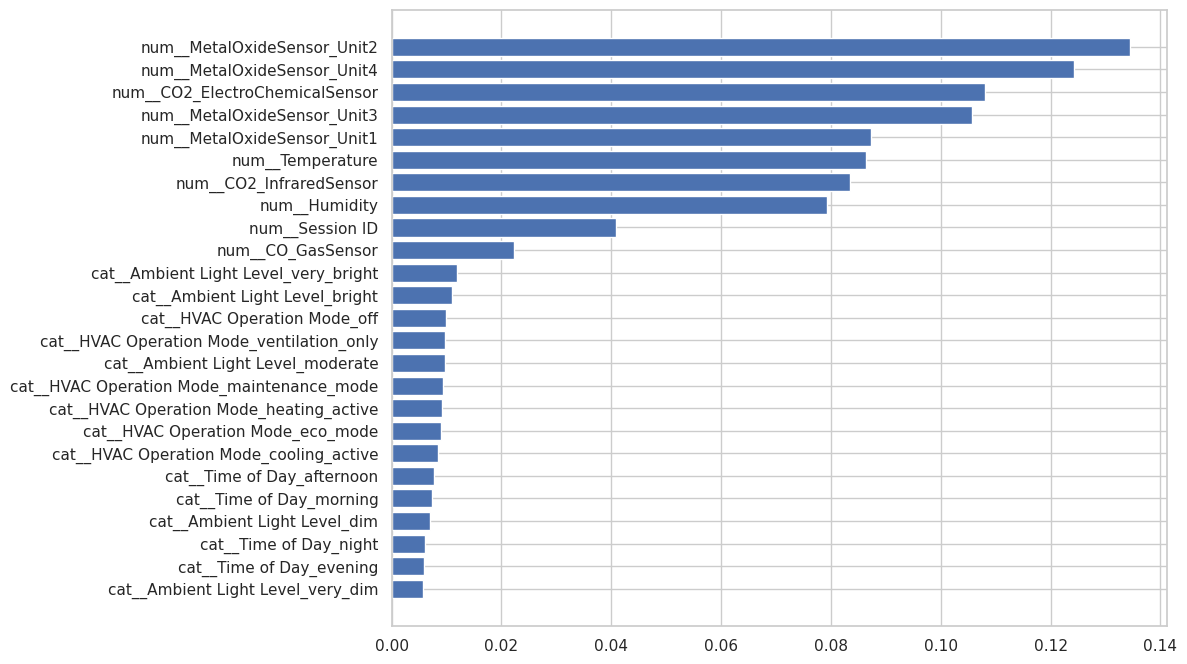

In [80]:
# Get feature importances and map them to column names
importances = rf_model.feature_importances_
feature_names = X_train.columns 
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# Sort for better visualisation
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False)

top_20 = feature_imp_df.head(50)

plt.figure(figsize=(10, 8))
plt.barh(top_20['Feature'], top_20['Importance'])
plt.gca().invert_yaxis()
plt.show()

## Based of this simple random forest model, we can see that the numeric data is the main contributor to predicting activity level. Hence, we will only be using numeric data in the training of our models. We have confirmed this to be the case as accuracy before and after dropping the categorical data remained the same.